**LAB 4 - Cluster 1**
[testo del link](https://)

In [ ]:
# ============================================================
# CELL 0 – Installazione dipendenze
# ============================================================

!pip install -U scikit-fuzzy
!pip install -U networkx

print("✅ Dipendenze installate correttamente!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 4.0 MB/s eta 0:00:00
✅ Dipendenze installate correttamente!


In [ ]:
# ============================================================
# CELL 1 – Setup e Import
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import cdist
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

import skfuzzy as fuzz
from skfuzzy import control as ctrl

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Tutte le librerie importate correttamente!")
print(f"   → numpy      : {np.__version__}")
print(f"   → pandas     : {pd.__version__}")
print(f"   → skfuzzy    : {fuzz.__version__}")


✅ Tutte le librerie importate correttamente!
   → numpy      : 2.0.2
   → pandas     : 2.2.2
   → skfuzzy    : 0.5.0


In [ ]:
# ============================================================
# CELL 1 – Setup
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import MinMaxScaler

import skfuzzy as fuzz
from skfuzzy import control as ctrl

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



In [ ]:
# ============================================================
# CELL 2a – Caricamento file su Google Colab
# ============================================================
from google.colab import files
import io

# Carica manualmente i file quando richiesto
print("📂 Carica il file Dataset_DAPPC_2026.xlsx")
uploaded = files.upload()

print("\n📂 Carica il file subject_assignments_10x10.xlsx")
uploaded2 = files.upload()

# Leggi i file caricati
df_full = pd.read_excel(io.BytesIO(uploaded['Dataset_DAPPC_2026.xlsx']))
assignment_10x10 = pd.read_excel(io.BytesIO(uploaded2['subject_assignments_10x10.xlsx']))

print("\n✅ File caricati correttamente!")
print(f"   → Dataset shape      : {df_full.shape}")
print(f"   → Assignment shape   : {assignment_10x10.shape}")


📂 Carica il file Dataset_DAPPC_2026.xlsx


Saving Dataset_DAPPC_2026.xlsx to Dataset_DAPPC_2026.xlsx

📂 Carica il file subject_assignments_10x10.xlsx


Saving subject_assignments_10x10.xlsx to subject_assignments_10x10.xlsx

✅ File caricati correttamente!
   → Dataset shape      : (4000, 120)
   → Assignment shape   : (3893, 11)


In [ ]:
# ============================================================
# CELL 2d – Prosegui con merge e selezione Cluster 1
#            (esegui DOPO una delle soluzioni sopra)
# ============================================================

id_cols     = ['subject_id', 'hadm_id', 'stay_id', 'ICU', 'ICU_intime', 'ICU_outtime']
outcome_col = 'outcome'
join_cols   = ['subject_id', 'hadm_id', 'stay_id']

# Colonne feature (esclude ID e outcome)
feature_cols = [c for c in df_full.columns if c not in id_cols + [outcome_col]]

# Merge con le assegnazioni cluster
df = df_full.merge(
    assignment_10x10[join_cols + ['cluster_id']],
    on=join_cols,
    how='inner'
)

print("✅ Merge completato!")
print(f"   → Dataset shape dopo merge : {df.shape}")
print(f"   → Numero feature           : {len(feature_cols)}")
print(f"\n📊 Distribuzione cluster:")
display(df['cluster_id'].value_counts().sort_index())


✅ Merge completato!
   → Dataset shape dopo merge : (3893, 121)
   → Numero feature           : 113

📊 Distribuzione cluster:


,count
cluster_id,
1,292
2,746
3,377
4,352
5,501
6,122
7,1503


In [ ]:
# ============================================================
# CELL 3 – Selezione Cluster 1 e feature selezionate da LAB3
# ============================================================

# Feature selezionate dall'ACO (Setup C, Cluster A = Cluster 1)
# NOTA: per il Cluster 1 (Cluster A) il Setup A aveva selezionato 5 feature.
# Usiamo le feature del Setup C che è il più robusto (10 feature).
# Se hai i risultati specifici del Cluster 1, sostituisci qui.

selected_features = [
    'first_plateau_pressure',
    'neuromuscular_blockers',
    'coronary_artery_disease',
    'charlson_comorbidity_index',
    'first_lactate',
    'pulmonary_hypertension',
    'std_mean_airway_pressure',
    'std_plateau_pressure',
]

# --- Filtra solo il Cluster 1 ---
cluster_df = df[df['cluster_id'] == 1].copy()

print(f"Cluster 1 – shape: {cluster_df.shape}")
print(f"\nFeature selezionate ({len(selected_features)}):", selected_features)
print("\nDistribuzione outcome nel Cluster 1:")
display(cluster_df[outcome_col].value_counts().sort_index().rename({
    0: '0 – Extubation Failure',
    1: '1 – Extubation Success',
    2: '2 – Death during ICU'
}))


Cluster 1 – shape: (292, 121)

Feature selezionate (8): ['first_plateau_pressure', 'neuromuscular_blockers', 'coronary_artery_disease', 'charlson_comorbidity_index', 'first_lactate', 'pulmonary_hypertension', 'std_mean_airway_pressure', 'std_plateau_pressure']

Distribuzione outcome nel Cluster 1:


,count
outcome,
0 – Extubation Failure,46
1 – Extubation Success,136
2 – Death during ICU,110


In [ ]:
# ============================================================
# CELL 4 – Statistiche descrittive per feature selezionate
# ============================================================

desc = cluster_df[selected_features].describe().T
desc['missing'] = cluster_df[selected_features].isna().sum()
desc['missing_%'] = (desc['missing'] / len(cluster_df) * 100).round(1)

print("Statistiche descrittive – Cluster 1:")
display(desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max',
              'missing', 'missing_%']].round(3))


Statistiche descrittive – Cluster 1:


,count,mean,std,min,25%,50%,75%,max,missing,missing_%
first_plateau_pressure,281.0,20.407,5.476,0.000,16.900,20.000,24.000,37.000,11,3.8
neuromuscular_blockers,292.0,0.171,0.377,0.000,0.000,0.000,0.000,1.000,0,0.0
coronary_artery_disease,292.0,0.134,0.341,0.000,0.000,0.000,0.000,1.000,0,0.0
charlson_comorbidity_index,292.0,5.822,2.875,0.000,4.000,6.000,8.000,15.000,0,0.0
first_lactate,287.0,3.257,3.692,0.500,1.200,2.000,3.600,26.000,5,1.7
pulmonary_hypertension,292.0,0.048,0.214,0.000,0.000,0.000,0.000,1.000,0,0.0
std_mean_airway_pressure,292.0,2.734,1.486,0.441,1.682,2.528,3.515,13.834,0,0.0
std_plateau_pressure,281.0,2.730,2.833,0.000,1.503,2.396,3.391,40.859,11,3.8


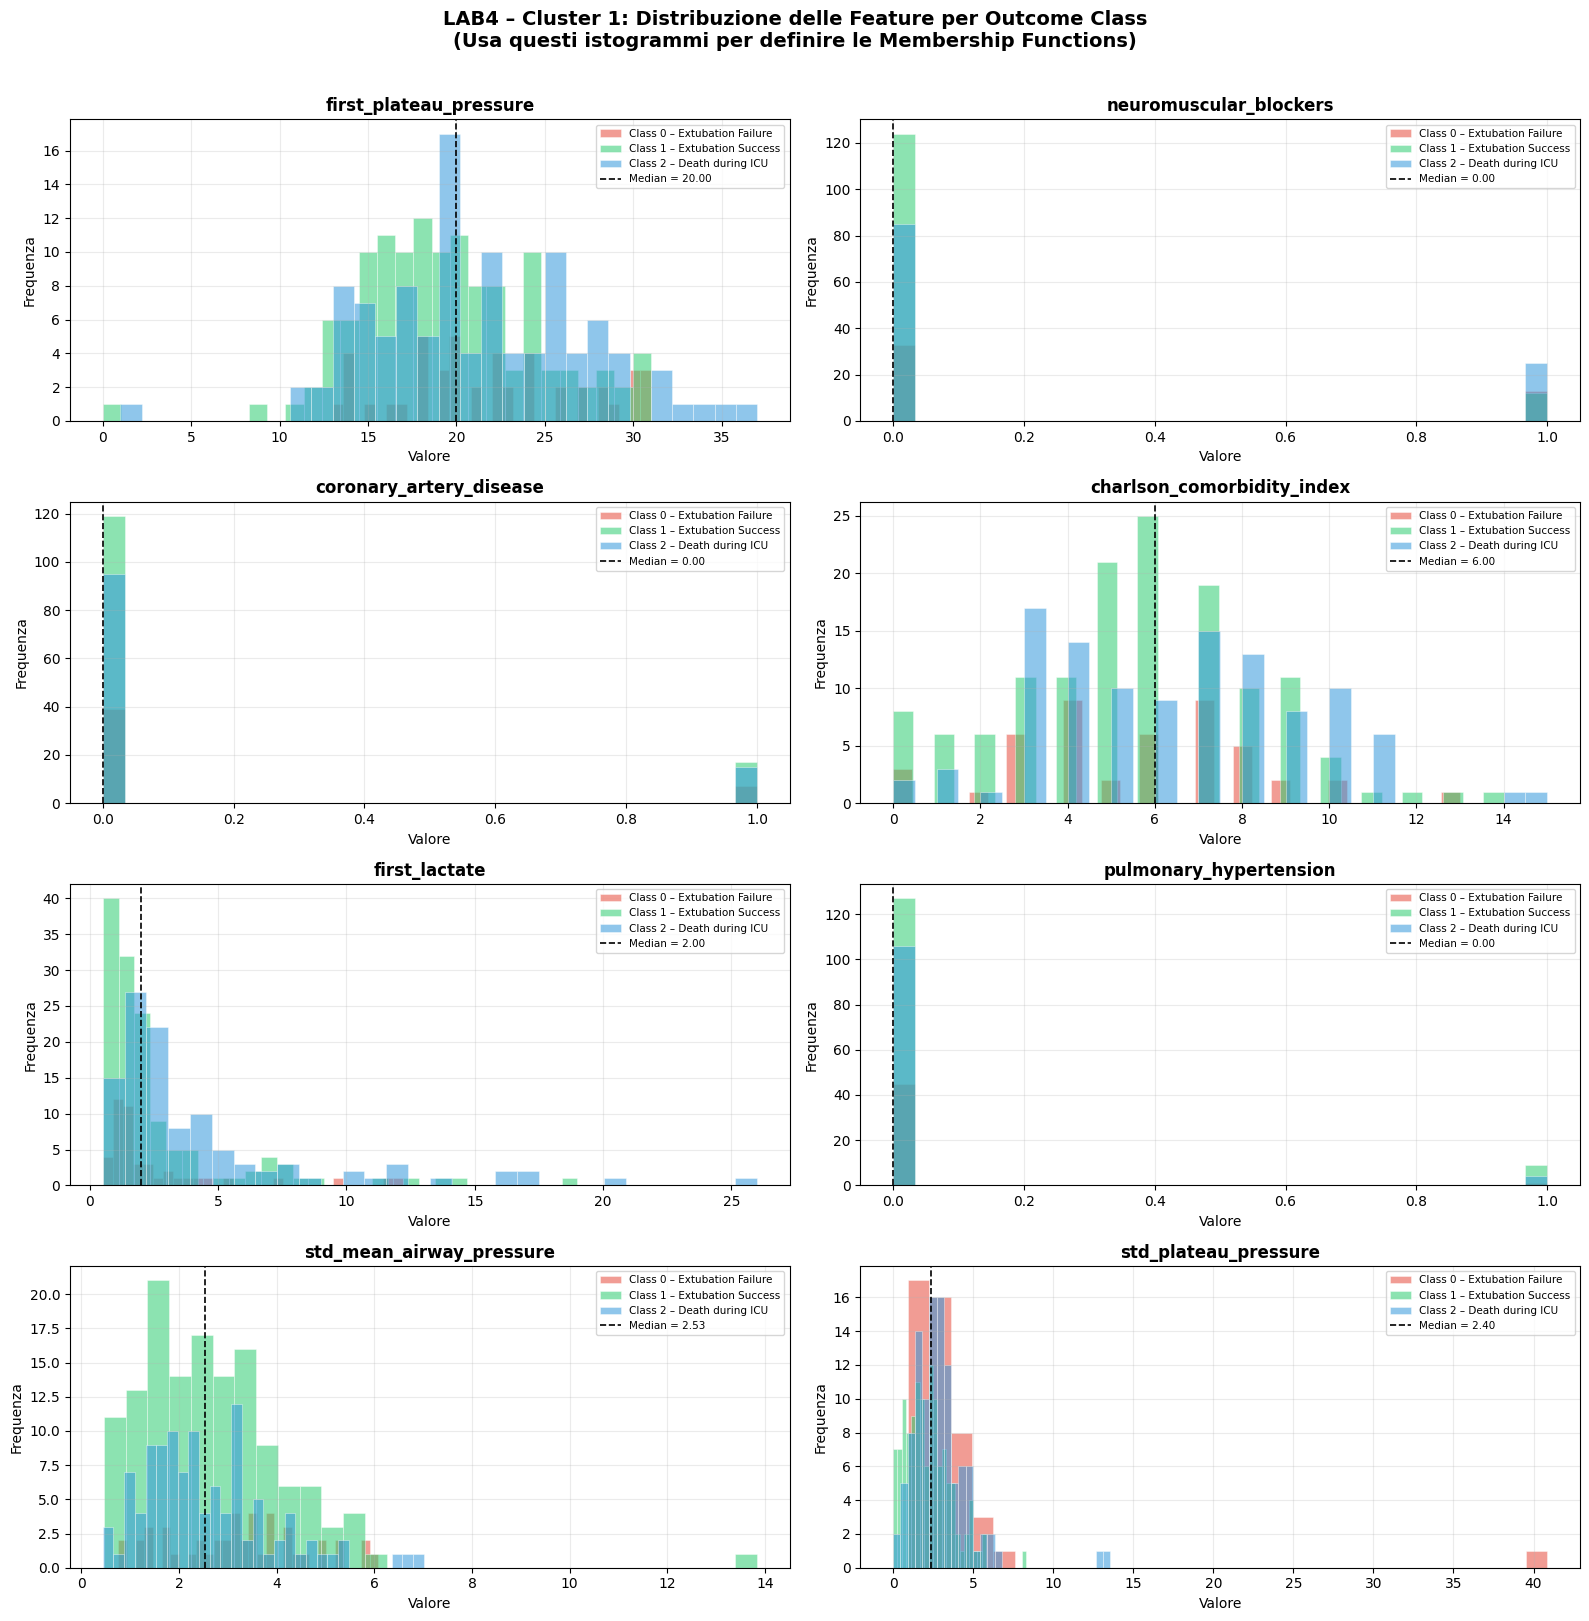

✅ Istogrammi salvati in 'histograms_cluster1.png'


In [ ]:
# ============================================================
# CELL 5 – ISTOGRAMMI per definire le Membership Functions
#           Separati per outcome class (0 / 1 / 2)
# ============================================================

outcome_labels = {
    0: 'Extubation Failure',
    1: 'Extubation Success',
    2: 'Death during ICU'
}
outcome_colors = {
    0: '#e74c3c',   # rosso
    1: '#2ecc71',   # verde
    2: '#3498db'    # blu
}

n_features = len(selected_features)
n_cols = 2
n_rows = (n_features + 1) // n_cols  # 4 righe x 2 colonne

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for idx, feat in enumerate(selected_features):
    ax = axes[idx]

    for outcome_val, label in outcome_labels.items():
        subset = cluster_df[cluster_df[outcome_col] == outcome_val][feat].dropna()
        ax.hist(
            subset,
            bins=30,
            alpha=0.55,
            color=outcome_colors[outcome_val],
            label=f'Class {outcome_val} – {label}',
            edgecolor='white',
            linewidth=0.5
        )

    # Linea verticale per la mediana globale
    global_median = cluster_df[feat].dropna().median()
    ax.axvline(global_median, color='black', linestyle='--',
               linewidth=1.2, label=f'Median = {global_median:.2f}')

    ax.set_title(f'{feat}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Valore', fontsize=10)
    ax.set_ylabel('Frequenza', fontsize=10)
    ax.legend(fontsize=7.5)
    ax.grid(True, alpha=0.25)

# Nascondi assi vuoti se n_features è dispari
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle(
    'LAB4 – Cluster 1: Distribuzione delle Feature per Outcome Class\n'
    '(Usa questi istogrammi per definire le Membership Functions)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('histograms_cluster1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Istogrammi salvati in 'histograms_cluster1.png'")


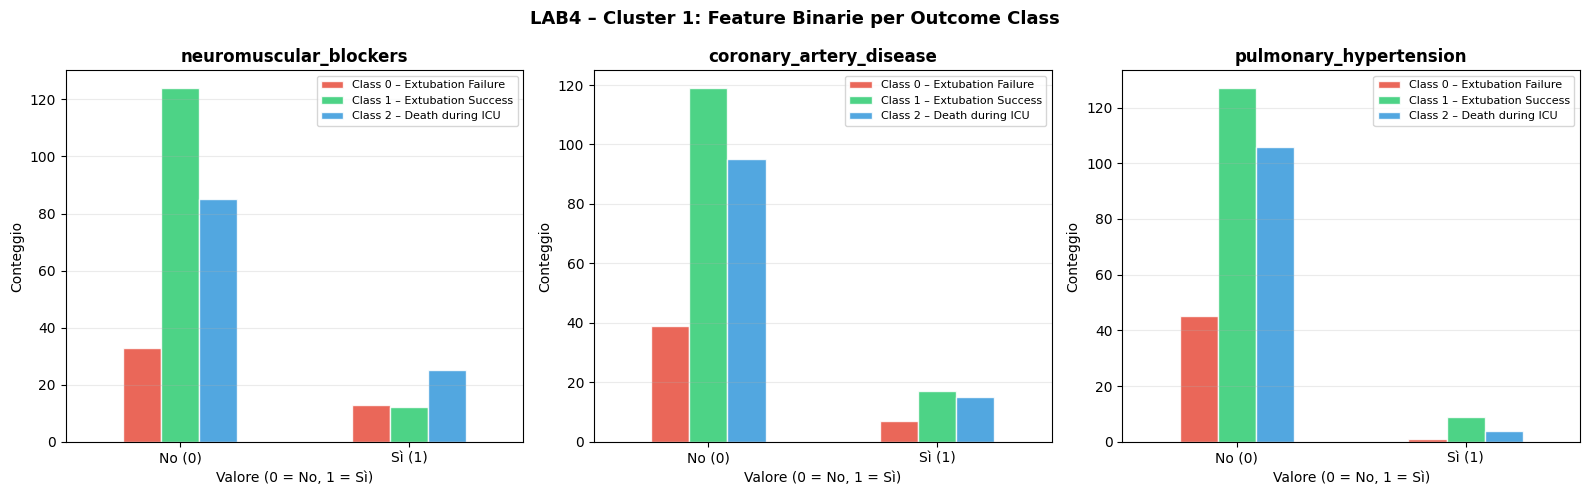

✅ Istogrammi binari salvati in 'histograms_binary_cluster1.png'


In [ ]:
# ============================================================
# CELL 6 – Istogrammi per feature BINARIE separati
#           (neuromuscular_blockers, coronary_artery_disease,
#            pulmonary_hypertension)
# ============================================================

binary_features = [
    'neuromuscular_blockers',
    'coronary_artery_disease',
    'pulmonary_hypertension'
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, feat in enumerate(binary_features):
    ax = axes[idx]

    # Conta per classe e valore binario
    ct = pd.crosstab(
        cluster_df[feat],
        cluster_df[outcome_col]
    )
    ct.columns = [f'Class {c} – {outcome_labels[c]}' for c in ct.columns]

    ct.plot(
        kind='bar',
        ax=ax,
        color=[outcome_colors[0], outcome_colors[1], outcome_colors[2]],
        edgecolor='white',
        alpha=0.85
    )

    ax.set_title(f'{feat}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Valore (0 = No, 1 = Sì)', fontsize=10)
    ax.set_ylabel('Conteggio', fontsize=10)
    ax.set_xticklabels(['No (0)', 'Sì (1)'], rotation=0)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25, axis='y')

fig.suptitle(
    'LAB4 – Cluster 1: Feature Binarie per Outcome Class',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('histograms_binary_cluster1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Istogrammi binari salvati in 'histograms_binary_cluster1.png'")


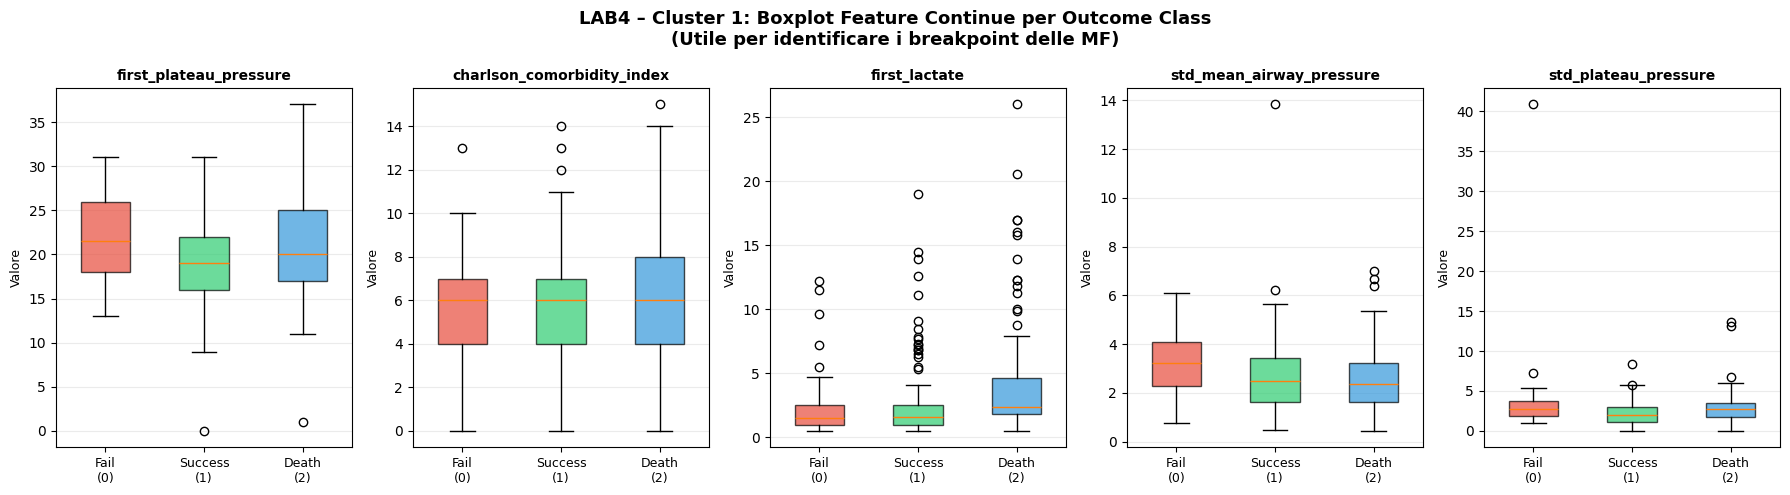

✅ Boxplot salvati in 'boxplots_cluster1.png'


In [ ]:
# ============================================================
# CELL 7 – Boxplot per confronto visivo tra classi
# ============================================================

continuous_features = [
    'first_plateau_pressure',
    'charlson_comorbidity_index',
    'first_lactate',
    'std_mean_airway_pressure',
    'std_plateau_pressure'
]

fig, axes = plt.subplots(1, len(continuous_features),
                          figsize=(18, 5))

for idx, feat in enumerate(continuous_features):
    ax = axes[idx]

    data_by_class = [
        cluster_df[cluster_df[outcome_col] == c][feat].dropna().values
        for c in [0, 1, 2]
    ]

    bp = ax.boxplot(
        data_by_class,
        patch_artist=True,
        notch=False,
        widths=0.5
    )

    for patch, color in zip(bp['boxes'],
                             [outcome_colors[0],
                              outcome_colors[1],
                              outcome_colors[2]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Fail\n(0)', 'Success\n(1)', 'Death\n(2)'],
                        fontsize=9)
    ax.set_ylabel('Valore', fontsize=9)
    ax.grid(True, alpha=0.25, axis='y')

fig.suptitle(
    'LAB4 – Cluster 1: Boxplot Feature Continue per Outcome Class\n'
    '(Utile per identificare i breakpoint delle MF)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('boxplots_cluster1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Boxplot salvati in 'boxplots_cluster1.png'")


In [ ]:
# ============================================================
# CELL 8 – Definizione Fuzzy Variables e Membership Functions
# ============================================================

fuzzy_inputs = {}

# ------------------------------------------------------------
# 1. first_plateau_pressure (range: 0–37 cmH2O)
# ------------------------------------------------------------
plateau = ctrl.Antecedent(np.arange(0, 38, 0.1), 'first_plateau_pressure')
plateau['low']    = fuzz.trapmf(plateau.universe, [0,  0,  15, 20])
plateau['normal'] = fuzz.trimf(plateau.universe,  [15, 20, 26])
plateau['high']   = fuzz.trapmf(plateau.universe, [22, 28, 37, 37])
fuzzy_inputs['first_plateau_pressure'] = plateau

# ------------------------------------------------------------
# 2. charlson_comorbidity_index (range: 0–15)
# ------------------------------------------------------------
charlson = ctrl.Antecedent(np.arange(0, 16, 0.1), 'charlson_comorbidity_index')
charlson['low']    = fuzz.trapmf(charlson.universe, [0, 0, 3,  5])
charlson['medium'] = fuzz.trimf(charlson.universe,  [3, 6, 9])
charlson['high']   = fuzz.trapmf(charlson.universe, [7, 10, 15, 15])
fuzzy_inputs['charlson_comorbidity_index'] = charlson

# ------------------------------------------------------------
# 3. first_lactate (range: 0.5–26 mmol/L)
# ------------------------------------------------------------
lactate = ctrl.Antecedent(np.arange(0, 27, 0.1), 'first_lactate')
lactate['normal']   = fuzz.trapmf(lactate.universe, [0,  0,   1.5, 2.5])
lactate['elevated'] = fuzz.trimf(lactate.universe,  [2,  4,   8])
lactate['critical'] = fuzz.trapmf(lactate.universe, [6,  10,  26, 26])
fuzzy_inputs['first_lactate'] = lactate

# ------------------------------------------------------------
# 4. std_mean_airway_pressure (range: 0.4–14)
# ------------------------------------------------------------
std_map = ctrl.Antecedent(np.arange(0, 14.1, 0.1), 'std_mean_airway_pressure')
std_map['stable']   = fuzz.trapmf(std_map.universe, [0,   0,   2,   3.5])
std_map['variable'] = fuzz.trimf(std_map.universe,  [2.5, 4,   6])
std_map['unstable'] = fuzz.trapmf(std_map.universe, [5,   7,   14,  14])
fuzzy_inputs['std_mean_airway_pressure'] = std_map

# ------------------------------------------------------------
# 5. std_plateau_pressure (range: 0–41)
# ------------------------------------------------------------
std_plat = ctrl.Antecedent(np.arange(0, 42, 0.1), 'std_plateau_pressure')
std_plat['stable']   = fuzz.trapmf(std_plat.universe, [0,  0,  2,   3.5])
std_plat['variable'] = fuzz.trimf(std_plat.universe,  [2.5, 4, 7])
std_plat['unstable'] = fuzz.trapmf(std_plat.universe, [5,  8,  41,  41])
fuzzy_inputs['std_plateau_pressure'] = std_plat

# ------------------------------------------------------------
# 6. neuromuscular_blockers (binaria: 0/1)
# ------------------------------------------------------------
nmb = ctrl.Antecedent(np.arange(0, 1.1, 0.01), 'neuromuscular_blockers')
nmb['absent']  = fuzz.trapmf(nmb.universe, [0,   0,   0.3, 0.5])
nmb['present'] = fuzz.trapmf(nmb.universe, [0.5, 0.7, 1,   1])
fuzzy_inputs['neuromuscular_blockers'] = nmb

# ------------------------------------------------------------
# 7. coronary_artery_disease (binaria: 0/1)
# ------------------------------------------------------------
cad = ctrl.Antecedent(np.arange(0, 1.1, 0.01), 'coronary_artery_disease')
cad['absent']  = fuzz.trapmf(cad.universe, [0,   0,   0.3, 0.5])
cad['present'] = fuzz.trapmf(cad.universe, [0.5, 0.7, 1,   1])
fuzzy_inputs['coronary_artery_disease'] = cad

# ------------------------------------------------------------
# 8. pulmonary_hypertension (binaria: 0/1)
# ------------------------------------------------------------
ph = ctrl.Antecedent(np.arange(0, 1.1, 0.01), 'pulmonary_hypertension')
ph['absent']  = fuzz.trapmf(ph.universe, [0,   0,   0.3, 0.5])
ph['present'] = fuzz.trapmf(ph.universe, [0.5, 0.7, 1,   1])
fuzzy_inputs['pulmonary_hypertension'] = ph

# ------------------------------------------------------------
# OUTPUT: clinical_risk (range: 0–100)
# ------------------------------------------------------------
clinical_risk = ctrl.Consequent(np.arange(0, 101, 1), 'clinical_risk')
clinical_risk['low']    = fuzz.trapmf(clinical_risk.universe, [0,  0,  20, 35])
clinical_risk['medium'] = fuzz.trimf(clinical_risk.universe,  [25, 50, 75])
clinical_risk['high']   = fuzz.trapmf(clinical_risk.universe, [65, 80, 100, 100])

print("✅ Fuzzy variables e MF definite correttamente!")
print(f"   → Numero input fuzzy : {len(fuzzy_inputs)}")
print(f"   → Output             : clinical_risk [0–100]")


✅ Fuzzy variables e MF definite correttamente!
   → Numero input fuzzy : 8
   → Output             : clinical_risk [0–100]


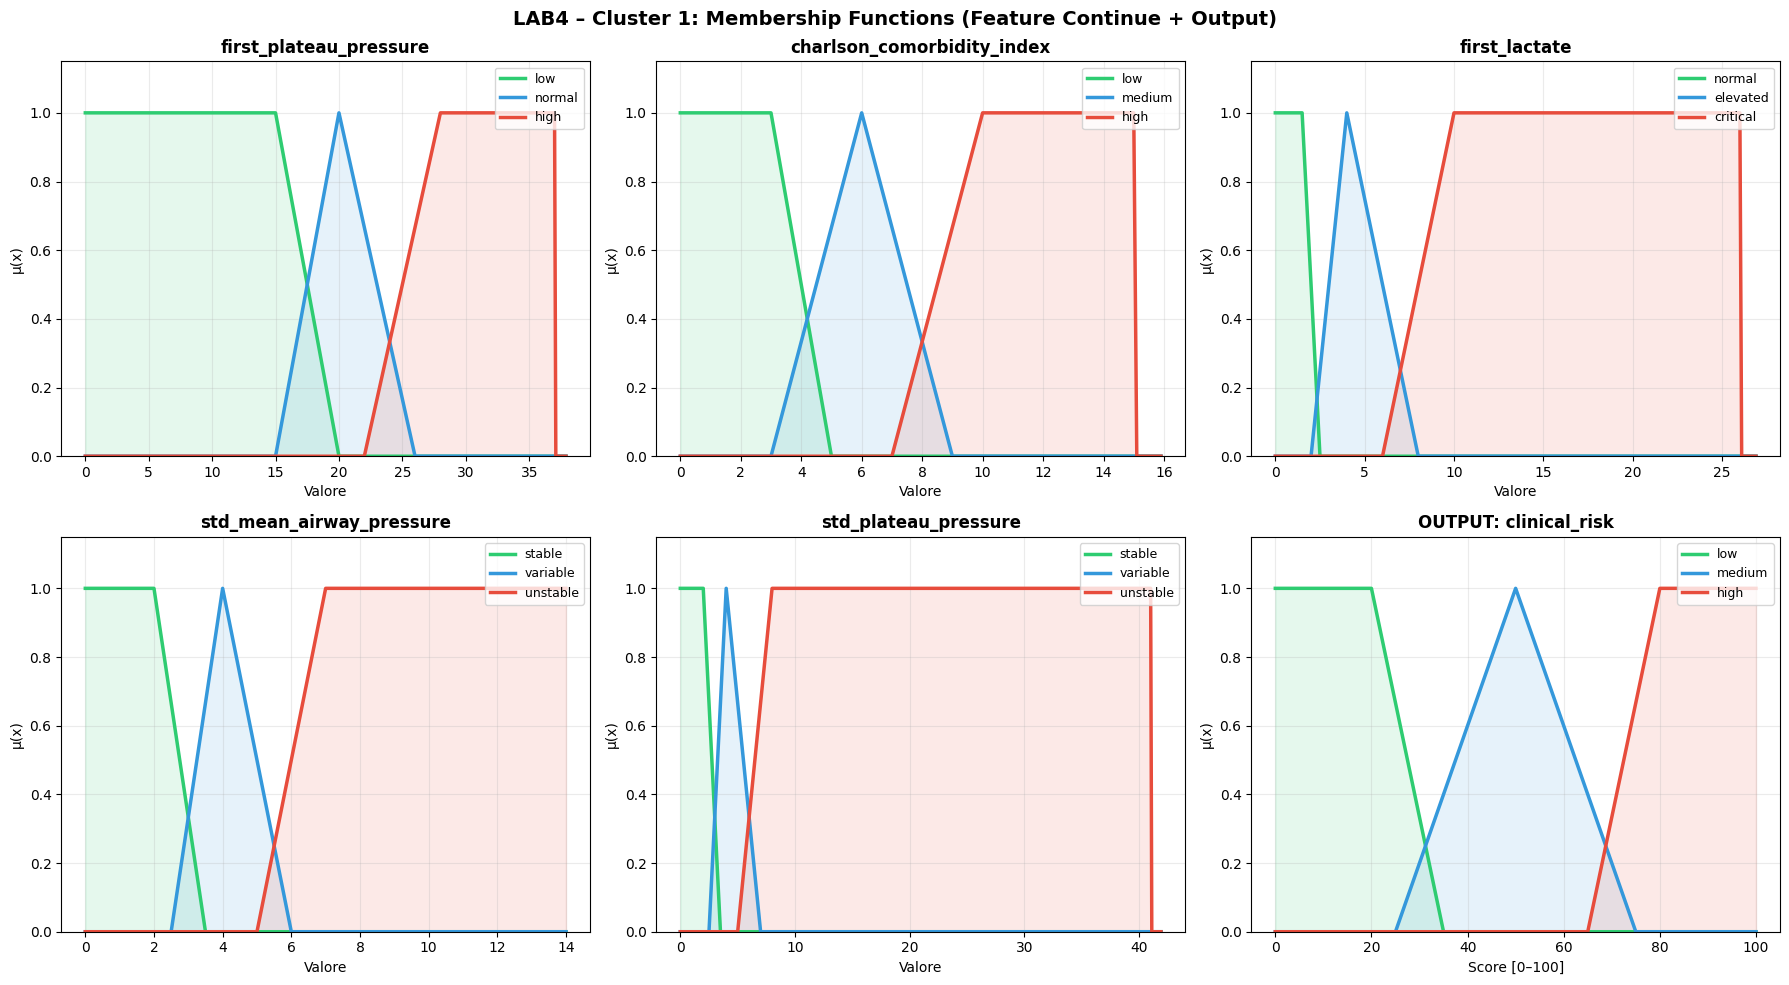

✅ MF continue visualizzate!


In [ ]:
# ============================================================
# CELL 9 – Visualizzazione MF: Feature Continue
# ============================================================

continuous_fuzzy = {
    k: v for k, v in fuzzy_inputs.items()
    if k not in ['neuromuscular_blockers',
                 'coronary_artery_disease',
                 'pulmonary_hypertension']
}

n = len(continuous_fuzzy)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors_mf = ['#2ecc71', '#3498db', '#e74c3c']

for idx, (feat_name, fuzzy_var) in enumerate(continuous_fuzzy.items()):
    ax = axes[idx]

    for i, (term_name, term_mf) in enumerate(fuzzy_var.terms.items()):
        ax.plot(
            fuzzy_var.universe,
            term_mf.mf,
            color=colors_mf[i % len(colors_mf)],
            linewidth=2.5,
            label=term_name
        )
        ax.fill_between(
            fuzzy_var.universe,
            term_mf.mf,
            alpha=0.12,
            color=colors_mf[i % len(colors_mf)]
        )

    ax.set_title(f'{feat_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Valore', fontsize=10)
    ax.set_ylabel('μ(x)', fontsize=10)
    ax.set_ylim([0, 1.15])
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.25)

# Visualizza anche clinical_risk nell'ultimo pannello
ax = axes[n]
for i, (term_name, term_mf) in enumerate(clinical_risk.terms.items()):
    ax.plot(
        clinical_risk.universe,
        term_mf.mf,
        color=colors_mf[i % len(colors_mf)],
        linewidth=2.5,
        label=term_name
    )
    ax.fill_between(
        clinical_risk.universe,
        term_mf.mf,
        alpha=0.12,
        color=colors_mf[i % len(colors_mf)]
    )
ax.set_title('OUTPUT: clinical_risk', fontsize=12, fontweight='bold')
ax.set_xlabel('Score [0–100]', fontsize=10)
ax.set_ylabel('μ(x)', fontsize=10)
ax.set_ylim([0, 1.15])
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.25)

# Nascondi pannelli vuoti
for idx in range(n + 1, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle(
    'LAB4 – Cluster 1: Membership Functions (Feature Continue + Output)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('MF_continuous_cluster1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ MF continue visualizzate!")


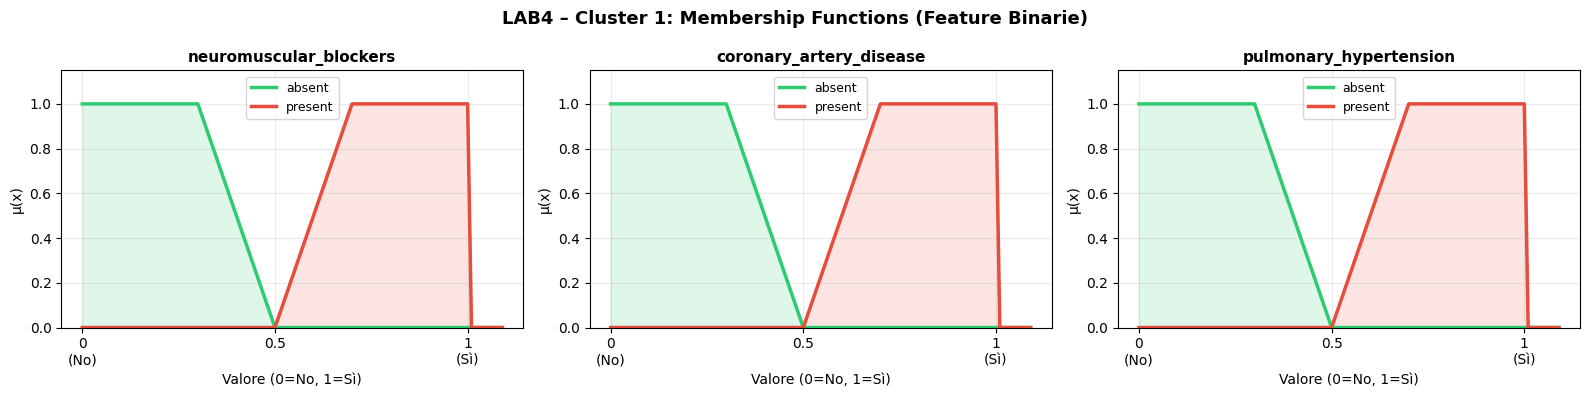

✅ MF binarie visualizzate!


In [ ]:
# ============================================================
# CELL 10 – Visualizzazione MF: Feature Binarie
# ============================================================

binary_fuzzy = {
    k: v for k, v in fuzzy_inputs.items()
    if k in ['neuromuscular_blockers',
             'coronary_artery_disease',
             'pulmonary_hypertension']
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors_bin = ['#2ecc71', '#e74c3c']

for idx, (feat_name, fuzzy_var) in enumerate(binary_fuzzy.items()):
    ax = axes[idx]

    for i, (term_name, term_mf) in enumerate(fuzzy_var.terms.items()):
        ax.plot(
            fuzzy_var.universe,
            term_mf.mf,
            color=colors_bin[i % len(colors_bin)],
            linewidth=2.5,
            label=term_name
        )
        ax.fill_between(
            fuzzy_var.universe,
            term_mf.mf,
            alpha=0.15,
            color=colors_bin[i % len(colors_bin)]
        )

    ax.set_title(f'{feat_name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Valore (0=No, 1=Sì)', fontsize=10)
    ax.set_ylabel('μ(x)', fontsize=10)
    ax.set_ylim([0, 1.15])
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels(['0\n(No)', '0.5', '1\n(Sì)'])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

fig.suptitle(
    'LAB4 – Cluster 1: Membership Functions (Feature Binarie)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('MF_binary_cluster1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ MF binarie visualizzate!")


In [ ]:
# ============================================================
# CELL 11 – Riepilogo MF definite
# ============================================================

print("=" * 65)
print("  RIEPILOGO MEMBERSHIP FUNCTIONS – CLUSTER 1")
print("=" * 65)

mf_summary = {
    'first_plateau_pressure'    : ['low', 'normal', 'high'],
    'charlson_comorbidity_index': ['low', 'medium', 'high'],
    'first_lactate'             : ['normal', 'elevated', 'critical'],
    'std_mean_airway_pressure'  : ['stable', 'variable', 'unstable'],
    'std_plateau_pressure'      : ['stable', 'variable', 'unstable'],
    'neuromuscular_blockers'    : ['absent', 'present'],
    'coronary_artery_disease'   : ['absent', 'present'],
    'pulmonary_hypertension'    : ['absent', 'present'],
}

for feat, terms in mf_summary.items():
    print(f"\n  📌 {feat}")
    for t in terms:
        print(f"      → '{t}'")

print(f"\n  🎯 OUTPUT: clinical_risk")
for t in ['low', 'medium', 'high']:
    print(f"      → '{t}'")

print("\n" + "=" * 65)
print("  ✅ Pronto per il clustering e la generazione delle regole!")
print("=" * 65)


  RIEPILOGO MEMBERSHIP FUNCTIONS – CLUSTER 1

  📌 first_plateau_pressure
      → 'low'
      → 'normal'
      → 'high'

  📌 charlson_comorbidity_index
      → 'low'
      → 'medium'
      → 'high'

  📌 first_lactate
      → 'normal'
      → 'elevated'
      → 'critical'

  📌 std_mean_airway_pressure
      → 'stable'
      → 'variable'
      → 'unstable'

  📌 std_plateau_pressure
      → 'stable'
      → 'variable'
      → 'unstable'

  📌 neuromuscular_blockers
      → 'absent'
      → 'present'

  📌 coronary_artery_disease
      → 'absent'
      → 'present'

  📌 pulmonary_hypertension
      → 'absent'
      → 'present'

  🎯 OUTPUT: clinical_risk
      → 'low'
      → 'medium'
      → 'high'

  ✅ Pronto per il clustering e la generazione delle regole!


In [ ]:
# ============================================================
# CELL 12 – Preparazione dati per il clustering
#            (Step 5 del notebook)
# ============================================================

from sklearn.impute import SimpleImputer

# Seleziona solo le feature scelte dall'ACO per il Cluster 1
X_cluster1 = cluster_df[selected_features].copy()

# Imputa i valori mancanti con la mediana
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_cluster1)
X_imputed = pd.DataFrame(X_imputed, columns=selected_features,
                          index=cluster_df.index)

print(f"NaN prima dell'imputazione : {X_cluster1.isna().sum().sum()}")
print(f"NaN dopo  l'imputazione   : X_imputed.isna().sum().sum()")

# Normalizzazione Min-Max sull'intero cluster
# (PRIMA di splittare per outcome, come da specifiche LAB4)
scaler_c1 = MinMaxScaler()
X_scaled_vals = scaler_c1.fit_transform(X_imputed)
X_scaled = pd.DataFrame(X_scaled_vals,
                         columns=selected_features,
                         index=cluster_df.index)

# Aggiungi la colonna outcome per lo split successivo
X_scaled[outcome_col] = cluster_df[outcome_col].values

print(f"\n✅ Dati pronti per il clustering!")
print(f"   → Shape matrice normalizzata : {X_scaled.shape}")
print(f"   → Range valori               : [{X_scaled[selected_features].min().min():.3f}"
      f", {X_scaled[selected_features].max().max():.3f}]")
print(f"\n📊 Distribuzione outcome nel Cluster 1:")
display(X_scaled[outcome_col].value_counts().sort_index().rename({
    0: '0 – Extubation Failure',
    1: '1 – Extubation Success',
    2: '2 – Death during ICU'
}))


NaN prima dell'imputazione : 27
NaN dopo  l'imputazione   : X_imputed.isna().sum().sum()

✅ Dati pronti per il clustering!
   → Shape matrice normalizzata : (292, 9)
   → Range valori               : [0.000, 1.000]

📊 Distribuzione outcome nel Cluster 1:


,count
outcome,
0 – Extubation Failure,46
1 – Extubation Success,136
2 – Death during ICU,110


Classe 0: 46 soggetti
Classe 1: 136 soggetti
Classe 2: 110 soggetti


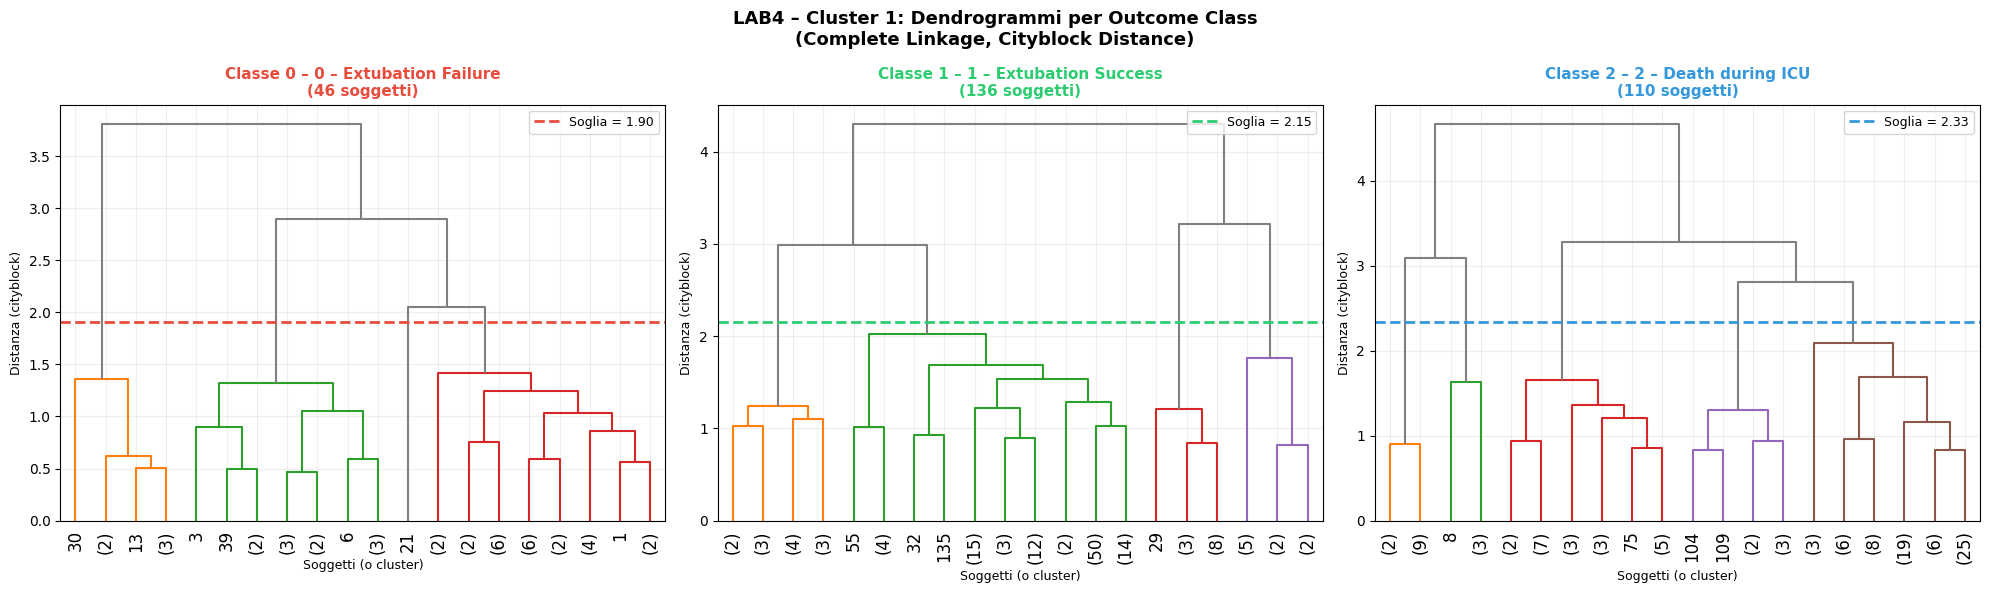

✅ Dendrogrammi salvati in 'dendrograms_cluster1.png'


In [ ]:
# ============================================================
# CELL 13 – Split per outcome e Clustering Gerarchico
#            (Steps 5–6 del notebook)
#            Metodo: complete linkage, metrica: cityblock
# ============================================================

# --- Split per outcome class ---
classes = {
    0: '0 – Extubation Failure',
    1: '1 – Extubation Success',
    2: '2 – Death during ICU'
}

data_by_class = {}
for c in [0, 1, 2]:
    mask = X_scaled[outcome_col] == c
    data_by_class[c] = X_scaled[mask][selected_features].values
    print(f"Classe {c}: {data_by_class[c].shape[0]} soggetti")

# --- Clustering gerarchico per ogni classe ---
linkage_matrices = {}
n_cols_dend = 3
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

colors_class = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}

for c in [0, 1, 2]:
    X_c = data_by_class[c]
    ax  = axes[c]

    # Linkage: complete + cityblock (come da specifiche LAB4)
    Z = linkage(X_c, method='complete', metric='cityblock')
    linkage_matrices[c] = Z

    # Calcola soglia automatica al 50% della distanza massima
    threshold = 0.5 * max(Z[:, 2])

    dendrogram(
        Z,
        ax=ax,
        truncate_mode='lastp',
        p=20,
        show_leaf_counts=True,
        leaf_rotation=90,
        color_threshold=threshold,
        above_threshold_color='grey'
    )

    ax.axhline(
        y=threshold,
        color=colors_class[c],
        linestyle='--',
        linewidth=2,
        label=f'Soglia = {threshold:.2f}'
    )

    ax.set_title(
        f'Classe {c} – {classes[c]}\n({X_c.shape[0]} soggetti)',
        fontsize=11, fontweight='bold',
        color=colors_class[c]
    )
    ax.set_xlabel('Soggetti (o cluster)', fontsize=9)
    ax.set_ylabel('Distanza (cityblock)', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

fig.suptitle(
    'LAB4 – Cluster 1: Dendrogrammi per Outcome Class\n'
    '(Complete Linkage, Cityblock Distance)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('dendrograms_cluster1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dendrogrammi salvati in 'dendrograms_cluster1.png'")


In [ ]:
# ============================================================
# CELL 14 – Taglio dendrogrammi e calcolo centroidi
#            (Steps 7–8 del notebook)
# ============================================================

# Numero di cluster per classe (puoi modificarlo dopo aver
# osservato i dendrogrammi)
n_clusters_per_class = {
    0: 2,   # Extubation Failure  (46 soggetti  → 2 cluster)
    1: 3,   # Extubation Success  (136 soggetti → 3 cluster)
    2: 3,   # Death during ICU    (110 soggetti → 3 cluster)
}

cluster_labels  = {}
centroids_norm  = {}   # centroidi nello spazio normalizzato
centroids_real  = {}   # centroidi nello spazio originale

print("=" * 65)
print("  CENTROIDI PER CLASSE (spazio normalizzato e reale)")
print("=" * 65)

for c in [0, 1, 2]:
    X_c = data_by_class[c]
    Z   = linkage_matrices[c]
    n_k = n_clusters_per_class[c]

    # Taglia il dendrogramma
    labels = fcluster(Z, n_k, criterion='maxclust')
    cluster_labels[c] = labels

    # Calcola centroidi normalizzati
    cents_norm = []
    for k in range(1, n_k + 1):
        mask   = labels == k
        if mask.sum() > 0:
            centroid = X_c[mask].mean(axis=0)
            cents_norm.append(centroid)

    cents_norm = np.array(cents_norm)
    centroids_norm[c] = cents_norm

    # Denormalizza i centroidi → spazio originale
    cents_real = scaler_c1.inverse_transform(cents_norm)
    cents_real = pd.DataFrame(cents_real,
                               columns=selected_features,
                               index=[f'C{c}_k{k+1}' for k in range(len(cents_norm))])
    centroids_real[c] = cents_real

    print(f"\n📍 Classe {c} – {classes[c]}")
    print(f"   Soggetti: {X_c.shape[0]}  |  Cluster: {n_k}")
    for k in range(1, n_k + 1):
        n_sogg = (labels == k).sum()
        print(f"   → Cluster {k}: {n_sogg} soggetti")
    print(f"\n   Centroidi (spazio reale):")
    display(cents_real.round(3))

print("\n✅ Centroidi calcolati e denormalizzati!")



  CENTROIDI PER CLASSE (spazio normalizzato e reale)

📍 Classe 0 – 0 – Extubation Failure
   Soggetti: 46  |  Cluster: 2
   → Cluster 1: 7 soggetti
   → Cluster 2: 39 soggetti

   Centroidi (spazio reale):


,first_plateau_pressure,neuromuscular_blockers,coronary_artery_disease,charlson_comorbidity_index,first_lactate,pulmonary_hypertension,std_mean_airway_pressure,std_plateau_pressure
C0_k1,23.429,0.000,1.0,6.571,1.700,0.143,3.163,2.265
C0_k2,21.700,0.333,0.0,5.385,2.679,0.000,3.237,3.967



📍 Classe 1 – 1 – Extubation Success
   Soggetti: 136  |  Cluster: 3
   → Cluster 1: 115 soggetti
   → Cluster 2: 12 soggetti
   → Cluster 3: 9 soggetti

   Centroidi (spazio reale):


,first_plateau_pressure,neuromuscular_blockers,coronary_artery_disease,charlson_comorbidity_index,first_lactate,pulmonary_hypertension,std_mean_airway_pressure,std_plateau_pressure
C1_k1,19.856,0.104,0.000,5.200,2.697,0.0,2.801,2.232
C1_k2,15.175,0.000,1.000,7.500,2.375,0.0,2.105,2.630
C1_k3,18.444,0.000,0.556,7.111,2.078,1.0,2.129,1.175



📍 Classe 2 – 2 – Death during ICU
   Soggetti: 110  |  Cluster: 3
   → Cluster 1: 15 soggetti
   → Cluster 2: 21 soggetti
   → Cluster 3: 74 soggetti

   Centroidi (spazio reale):


,first_plateau_pressure,neuromuscular_blockers,coronary_artery_disease,charlson_comorbidity_index,first_lactate,pulmonary_hypertension,std_mean_airway_pressure,std_plateau_pressure
C2_k1,20.207,0.267,1.0,8.933,2.553,0.067,2.519,2.429
C2_k2,23.190,1.000,0.0,4.238,3.810,0.000,3.232,3.868
C2_k3,20.576,0.000,0.0,6.338,4.768,0.041,2.402,2.792



✅ Centroidi calcolati e denormalizzati!


In [ ]:
# ============================================================
# CELL 15 – Generazione automatica delle regole fuzzy
#            + Aggiunta manuale di regole cliniche
#            (Steps 9–10 del notebook)
# ============================================================

# --- Funzione: mappa un valore reale alla MF con μ massimo ---
def get_best_mf(value, fuzzy_var):
    """
    Dato un valore reale, restituisce il termine linguistico
    della MF con grado di appartenenza massimo.
    """
    best_term = None
    best_mu   = -1.0

    for term_name in fuzzy_var.terms:
        mu = fuzz.interp_membership(
            fuzzy_var.universe,
            fuzzy_var[term_name].mf,
            value
        )
        if mu > best_mu:
            best_mu   = mu
            best_term = term_name

    return best_term, best_mu


# --- Mappa outcome → termine linguistico del clinical_risk ---
outcome_to_risk = {
    0: 'medium',   # Extubation Failure → rischio medio
    1: 'low',      # Extubation Success → rischio basso
    2: 'high',     # Death during ICU   → rischio alto
}

# --- Generazione automatica delle regole dai centroidi ---
print("=" * 70)
print("  GENERAZIONE AUTOMATICA REGOLE DAI CENTROIDI")
print("=" * 70)

auto_rules_data = []   # lista dizionari per il DataFrame

for c in [0, 1, 2]:
    cents = centroids_real[c]
    print(f"\n{'─'*70}")
    print(f"📋 Classe {c} – {classes[c]}  →  clinical_risk = '{outcome_to_risk[c]}'")
    print(f"{'─'*70}")

    for idx, (row_name, row) in enumerate(cents.iterrows()):
        rule_dict = {}

        for feat in selected_features:
            fuzzy_var        = fuzzy_inputs[feat]
            best_term, best_mu = get_best_mf(row[feat], fuzzy_var)
            rule_dict[feat]  = best_term

        rule_dict['clinical_risk'] = outcome_to_risk[c]
        rule_dict['source']        = 'auto'
        rule_dict['class']         = c
        rule_dict['centroid_id']   = row_name
        auto_rules_data.append(rule_dict)

        # Stampa regola leggibile
        antecedents = " AND\n      ".join(
            [f"{f} = '{rule_dict[f]}'" for f in selected_features]
        )
        print(f"\n  📌 Regola AUTO {len(auto_rules_data)} ({row_name}):")
        print(f"  IF {antecedents}")
        print(f"  THEN clinical_risk = '{outcome_to_risk[c]}'")


# --- Aggiunta manuale di regole clinicamente sensate ---
print(f"\n{'=' * 70}")
print("  AGGIUNTA MANUALE DI REGOLE CLINICHE")
print("=" * 70)

manual_rules_data = [

    # ── REGOLE PER RISCHIO ALTO (Death during ICU) ──────────────────
    # Lattato critico + alta comorbidità → morte quasi certa
    {
        'first_plateau_pressure'    : 'high',
        'neuromuscular_blockers'    : 'present',
        'coronary_artery_disease'   : 'absent',
        'charlson_comorbidity_index': 'high',
        'first_lactate'             : 'critical',
        'pulmonary_hypertension'    : 'absent',
        'std_mean_airway_pressure'  : 'unstable',
        'std_plateau_pressure'      : 'unstable',
        'clinical_risk'             : 'high',
        'source'                    : 'manual',
        'class'                     : 2,
        'centroid_id'               : 'manual_1'
    },
    # Pressione plateau alta + ipertensione polmonare + lattato critico
    {
        'first_plateau_pressure'    : 'high',
        'neuromuscular_blockers'    : 'absent',
        'coronary_artery_disease'   : 'absent',
        'charlson_comorbidity_index': 'high',
        'first_lactate'             : 'critical',
        'pulmonary_hypertension'    : 'present',
        'std_mean_airway_pressure'  : 'unstable',
        'std_plateau_pressure'      : 'unstable',
        'clinical_risk'             : 'high',
        'source'                    : 'manual',
        'class'                     : 2,
        'centroid_id'               : 'manual_2'
    },
    # CAD + alta comorbidità + lattato critico → alto rischio morte
    {
        'first_plateau_pressure'    : 'normal',
        'neuromuscular_blockers'    : 'absent',
        'coronary_artery_disease'   : 'present',
        'charlson_comorbidity_index': 'high',
        'first_lactate'             : 'critical',
        'pulmonary_hypertension'    : 'absent',
        'std_mean_airway_pressure'  : 'variable',
        'std_plateau_pressure'      : 'variable',
        'clinical_risk'             : 'high',
        'source'                    : 'manual',
        'class'                     : 2,
        'centroid_id'               : 'manual_3'
    },

    # ── REGOLE PER RISCHIO BASSO (Extubation Success) ───────────────
    # Paziente giovane/sano: bassa comorbidità, lattato normale,
    # pressioni stabili → successo estubazione
    {
        'first_plateau_pressure'    : 'low',
        'neuromuscular_blockers'    : 'absent',
        'coronary_artery_disease'   : 'absent',
        'charlson_comorbidity_index': 'low',
        'first_lactate'             : 'normal',
        'pulmonary_hypertension'    : 'absent',
        'std_mean_airway_pressure'  : 'stable',
        'std_plateau_pressure'      : 'stable',
        'clinical_risk'             : 'low',
        'source'                    : 'manual',
        'class'                     : 1,
        'centroid_id'               : 'manual_4'
    },
    # Pressione plateau normale + lattato normale + no comorbidità
    {
        'first_plateau_pressure'    : 'normal',
        'neuromuscular_blockers'    : 'absent',
        'coronary_artery_disease'   : 'absent',
        'charlson_comorbidity_index': 'low',
        'first_lactate'             : 'normal',
        'pulmonary_hypertension'    : 'absent',
        'std_mean_airway_pressure'  : 'stable',
        'std_plateau_pressure'      : 'stable',
        'clinical_risk'             : 'low',
        'source'                    : 'manual',
        'class'                     : 1,
        'centroid_id'               : 'manual_5'
    },

    # ── REGOLE PER RISCHIO MEDIO (Extubation Failure) ───────────────
    # Comorbidità media + lattato elevato → fallimento estubazione
    {
        'first_plateau_pressure'    : 'normal',
        'neuromuscular_blockers'    : 'absent',
        'coronary_artery_disease'   : 'absent',
        'charlson_comorbidity_index': 'medium',
        'first_lactate'             : 'elevated',
        'pulmonary_hypertension'    : 'absent',
        'std_mean_airway_pressure'  : 'variable',
        'std_plateau_pressure'      : 'stable',
        'clinical_risk'             : 'medium',
        'source'                    : 'manual',
        'class'                     : 0,
        'centroid_id'               : 'manual_6'
    },
    # CAD presente + comorbidità media → fallimento estubazione
    {
        'first_plateau_pressure'    : 'normal',
        'neuromuscular_blockers'    : 'absent',
        'coronary_artery_disease'   : 'present',
        'charlson_comorbidity_index': 'medium',
        'first_lactate'             : 'elevated',
        'pulmonary_hypertension'    : 'absent',
        'std_mean_airway_pressure'  : 'stable',
        'std_plateau_pressure'      : 'stable',
        'clinical_risk'             : 'medium',
        'source'                    : 'manual',
        'class'                     : 0,
        'centroid_id'               : 'manual_7'
    },
]

# Stampa regole manuali
for i, r in enumerate(manual_rules_data):
    antecedents = " AND\n      ".join(
        [f"{f} = '{r[f]}'" for f in selected_features]
    )
    print(f"\n  📌 Regola MANUALE {i+1} ({r['centroid_id']}):")
    print(f"  IF {antecedents}")
    print(f"  THEN clinical_risk = '{r['clinical_risk']}'")


# --- Unisci tutte le regole in un unico DataFrame ---
all_rules_data = auto_rules_data + manual_rules_data
rules_df = pd.DataFrame(all_rules_data)

# Riordina colonne
col_order = selected_features + ['clinical_risk', 'source', 'class', 'centroid_id']
rules_df  = rules_df[col_order]

# Rimuovi duplicati (stessa combinazione di antecedenti)
rules_df_nodup = rules_df.drop_duplicates(subset=selected_features + ['clinical_risk'])

print(f"\n\n{'=' * 70}")
print(f"  📊 RIEPILOGO RULE BASE")
print(f"{'=' * 70}")
print(f"  Regole automatiche  : {len(auto_rules_data)}")
print(f"  Regole manuali      : {len(manual_rules_data)}")
print(f"  Totale              : {len(all_rules_data)}")
print(f"  Dopo deduplicazione : {len(rules_df_nodup)}")
print(f"\n  Distribuzione per classe:")
display(rules_df_nodup['class'].value_counts().sort_index().rename({
    0: '0 – Extubation Failure',
    1: '1 – Extubation Success',
    2: '2 – Death during ICU'
}))

print(f"\n  Distribuzione per sorgente:")
display(rules_df_nodup['source'].value_counts())

# Salva su Excel
rules_df_nodup.to_excel('fuzzy_rules_cluster1.xlsx', index=False)
print(f"\n✅ Rule base salvata in 'fuzzy_rules_cluster1.xlsx'")

# Visualizza tabella finale
print(f"\n📋 Rule Base completa:")
display(rules_df_nodup[selected_features + ['clinical_risk', 'source']].reset_index(drop=True))


  GENERAZIONE AUTOMATICA REGOLE DAI CENTROIDI

──────────────────────────────────────────────────────────────────────
📋 Classe 0 – 0 – Extubation Failure  →  clinical_risk = 'medium'
──────────────────────────────────────────────────────────────────────

  📌 Regola AUTO 1 (C0_k1):
  IF first_plateau_pressure = 'normal' AND
      neuromuscular_blockers = 'absent' AND
      coronary_artery_disease = 'present' AND
      charlson_comorbidity_index = 'medium' AND
      first_lactate = 'normal' AND
      pulmonary_hypertension = 'absent' AND
      std_mean_airway_pressure = 'variable' AND
      std_plateau_pressure = 'stable'
  THEN clinical_risk = 'medium'

  📌 Regola AUTO 2 (C0_k2):
  IF first_plateau_pressure = 'normal' AND
      neuromuscular_blockers = 'absent' AND
      coronary_artery_disease = 'absent' AND
      charlson_comorbidity_index = 'medium' AND
      first_lactate = 'elevated' AND
      pulmonary_hypertension = 'absent' AND
      std_mean_airway_pressure = 'variable' AND
   

,count
class,
0 – Extubation Failure,4
1 – Extubation Success,5
2 – Death during ICU,6



  Distribuzione per sorgente:


,count
source,
auto,8
manual,7



✅ Rule base salvata in 'fuzzy_rules_cluster1.xlsx'

📋 Rule Base completa:


,first_plateau_pressure,neuromuscular_blockers,coronary_artery_disease,charlson_comorbidity_index,first_lactate,pulmonary_hypertension,std_mean_airway_pressure,std_plateau_pressure,clinical_risk,source
0,normal,absent,present,medium,normal,absent,variable,stable,medium,auto
1,normal,absent,absent,medium,elevated,absent,variable,variable,medium,auto
2,normal,absent,absent,medium,elevated,absent,stable,stable,low,auto
3,low,absent,present,medium,elevated,absent,stable,stable,low,auto
4,normal,absent,present,medium,normal,present,stable,stable,low,auto
5,normal,absent,present,high,elevated,absent,stable,stable,high,auto
6,normal,present,absent,medium,elevated,absent,variable,variable,high,auto
7,normal,absent,absent,medium,elevated,absent,stable,stable,high,auto
8,high,present,absent,high,critical,absent,unstable,unstable,high,manual
9,high,absent,absent,high,critical,present,unstable,unstable,high,manual


In [ ]:
# ============================================================
# CELL 16 (v2) – Ridefinizione MF binarie + Costruzione FIS
#               con regole semplificate (4-5 feature chiave)
# ============================================================

# --- Ridefinisci MF binarie con sigmf più morbide ---
nmb['absent']  = fuzz.sigmf(nmb.universe, 0.3, -20)
nmb['present'] = fuzz.sigmf(nmb.universe, 0.7,  20)

cad['absent']  = fuzz.sigmf(cad.universe, 0.3, -20)
cad['present'] = fuzz.sigmf(cad.universe, 0.7,  20)

ph['absent']   = fuzz.sigmf(ph.universe,  0.3, -20)
ph['present']  = fuzz.sigmf(ph.universe,  0.7,  20)

print("✅ MF binarie ridefinite con sigmf!")

# --- Ridefinisci fuzzy_vars ---
fuzzy_vars = {
    'first_plateau_pressure'    : plateau,
    'neuromuscular_blockers'    : nmb,
    'coronary_artery_disease'   : cad,
    'charlson_comorbidity_index': charlson,
    'first_lactate'             : lactate,
    'pulmonary_hypertension'    : ph,
    'std_mean_airway_pressure'  : std_map,
    'std_plateau_pressure'      : std_plat,
}

print("✅ fuzzy_vars ridefinito!")

# --- Feature chiave per le regole (le più discriminanti) ---
features_key = [
    'first_plateau_pressure',
    'charlson_comorbidity_index',
    'first_lactate',
    'std_mean_airway_pressure',
]

fuzzy_vars_key = {k: fuzzy_vars[k] for k in features_key}

print("✅ fuzzy_vars_key definito!")
print(f"   → Feature chiave: {list(fuzzy_vars_key.keys())}")

# --- Nuova rule base semplificata ---
# Ogni regola usa solo 2-4 feature continue
# μ_rule = min(μ1, μ2, ...) → molto più facile da attivare

rules_simplified = [

    # ══════════════════════════════════════════════════════
    # RISCHIO BASSO → Extubation Success
    # ══════════════════════════════════════════════════════
    # Pressione bassa + bassa comorbidità +
    # lattato normale + ventilazione stabile
    ctrl.Rule(
        plateau['low']    &
        charlson['low']   &
        lactate['normal'] &
        std_map['stable'],
        clinical_risk['low']
    ),
    # Pressione normale + bassa comorbidità +
    # lattato normale + ventilazione stabile
    ctrl.Rule(
        plateau['normal'] &
        charlson['low']   &
        lactate['normal'] &
        std_map['stable'],
        clinical_risk['low']
    ),
    # Pressione bassa + comorbidità media +
    # lattato normale + ventilazione stabile
    ctrl.Rule(
        plateau['low']     &
        charlson['medium'] &
        lactate['normal']  &
        std_map['stable'],
        clinical_risk['low']
    ),
    # Pressione normale + comorbidità media +
    # lattato normale + ventilazione stabile
    ctrl.Rule(
        plateau['normal']  &
        charlson['medium'] &
        lactate['normal']  &
        std_map['stable'],
        clinical_risk['low']
    ),
    # Lattato normale + comorbidità bassa
    # → sempre basso rischio (regola corta)
    ctrl.Rule(
        lactate['normal'] &
        charlson['low'],
        clinical_risk['low']
    ),
    # Lattato normale + ventilazione stabile
    # → basso rischio
    ctrl.Rule(
        lactate['normal'] &
        std_map['stable'],
        clinical_risk['low']
    ),

    # ══════════════════════════════════════════════════════
    # RISCHIO MEDIO → Extubation Failure
    # ══════════════════════════════════════════════════════
    # Pressione normale + comorbidità media +
    # lattato elevato + variabilità moderata
    ctrl.Rule(
        plateau['normal']   &
        charlson['medium']  &
        lactate['elevated'] &
        std_map['variable'],
        clinical_risk['medium']
    ),
    # Pressione normale + comorbidità media +
    # lattato elevato + ventilazione stabile
    ctrl.Rule(
        plateau['normal']   &
        charlson['medium']  &
        lactate['elevated'] &
        std_map['stable'],
        clinical_risk['medium']
    ),
    # Pressione alta + comorbidità media +
    # lattato elevato + ventilazione stabile
    ctrl.Rule(
        plateau['high']     &
        charlson['medium']  &
        lactate['elevated'] &
        std_map['stable'],
        clinical_risk['medium']
    ),
    # Lattato elevato + comorbidità media
    # → rischio medio (regola corta)
    ctrl.Rule(
        lactate['elevated'] &
        charlson['medium'],
        clinical_risk['medium']
    ),
    # Pressione alta + variabilità moderata
    # → rischio medio
    ctrl.Rule(
        plateau['high']    &
        std_map['variable'],
        clinical_risk['medium']
    ),
    # Lattato elevato + ventilazione variabile
    # → rischio medio
    ctrl.Rule(
        lactate['elevated'] &
        std_map['variable'],
        clinical_risk['medium']
    ),

    # ══════════════════════════════════════════════════════
    # RISCHIO ALTO → Death during ICU
    # ══════════════════════════════════════════════════════
    # Alta comorbidità + lattato critico
    # → morte quasi certa
    ctrl.Rule(
        charlson['high']    &
        lactate['critical'],
        clinical_risk['high']
    ),
    # Pressione alta + lattato critico
    # → morte
    ctrl.Rule(
        plateau['high']     &
        lactate['critical'],
        clinical_risk['high']
    ),
    # Lattato critico + ventilazione instabile
    # → morte
    ctrl.Rule(
        lactate['critical'] &
        std_map['unstable'],
        clinical_risk['high']
    ),
    # Alta comorbidità + ventilazione instabile
    # → morte
    ctrl.Rule(
        charlson['high']    &
        std_map['unstable'],
        clinical_risk['high']
    ),
    # Pressione alta + alta comorbidità
    # → morte
    ctrl.Rule(
        plateau['high']     &
        charlson['high'],
        clinical_risk['high']
    ),
    # Lattato critico da solo
    # → sempre alto rischio
    ctrl.Rule(
        lactate['critical'],
        clinical_risk['high']
    ),
    # Alta comorbidità + lattato elevato
    # → alto rischio
    ctrl.Rule(
        charlson['high']    &
        lactate['elevated'],
        clinical_risk['high']
    ),
    # Pressione alta + lattato elevato + instabile
    # → alto rischio
    ctrl.Rule(
        plateau['high']     &
        lactate['elevated'] &
        std_map['unstable'],
        clinical_risk['high']
    ),
]

print(f"\n✅ Regole semplificate create: {len(rules_simplified)}")
print(f"   → Regole low    (Success) : "
      f"{sum(1 for r in rules_simplified if 'low' in str(r.consequent))}")
print(f"   → Regole medium (Failure) : "
      f"{sum(1 for r in rules_simplified if 'medium' in str(r.consequent))}")
print(f"   → Regole high   (Death)   : "
      f"{sum(1 for r in rules_simplified if 'high' in str(r.consequent))}")

# --- Costruisci il nuovo FIS ---
try:
    fis_ctrl_v2 = ctrl.ControlSystem(rules_simplified)
    fis_sim_v2  = ctrl.ControlSystemSimulation(fis_ctrl_v2)
    print(f"\n✅ FIS v2 costruito correttamente!")
    print(f"   → Numero regole        : {len(rules_simplified)}")
    print(f"   → Feature per regola   : 1–4 (invece di 8)")
    print(f"   → Output               : clinical_risk [0–100]")
except Exception as e:
    print(f"\n❌ Errore nella costruzione del FIS: {e}")


✅ MF binarie ridefinite con sigmf!
✅ fuzzy_vars ridefinito!
✅ fuzzy_vars_key definito!
   → Feature chiave: ['first_plateau_pressure', 'charlson_comorbidity_index', 'first_lactate', 'std_mean_airway_pressure']

✅ Regole semplificate create: 20
   → Regole low    (Success) : 6
   → Regole medium (Failure) : 6
   → Regole high   (Death)   : 8

✅ FIS v2 costruito correttamente!
   → Numero regole        : 20
   → Feature per regola   : 1–4 (invece di 8)
   → Output               : clinical_risk [0–100]


In [ ]:
# ============================================================
# CELL 17 (v2) – Applicazione FIS v2 al Cluster 1
# ============================================================

from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# --- Ridefinisci X_real (dati imputati in spazio reale) ---
X_real = X_imputed.copy()
X_real[outcome_col] = cluster_df[outcome_col].values

print(f"✅ X_real ridefinito!")
print(f"   → Shape : {X_real.shape}")
print(f"   → Feature: {list(X_imputed.columns)}")

# --- Ridefinisci labels_class ---
labels_class = {
    0: '0–Extubation Failure',
    1: '1–Extubation Success',
    2: '2–Death during ICU'
}

results_v2     = []
fallback_count = 0

print("\n🔄 Applicazione FIS v2 in corso...")

for i, (idx, row) in enumerate(tqdm(X_real.iterrows(),
                                     total=len(X_real),
                                     desc="FIS v2 inference")):
    try:
        # Imposta solo le 4 feature chiave
        fis_sim_v2.input['first_plateau_pressure']     = float(np.clip(
            row['first_plateau_pressure'],    0,  37))
        fis_sim_v2.input['charlson_comorbidity_index'] = float(np.clip(
            row['charlson_comorbidity_index'], 0,  15))
        fis_sim_v2.input['first_lactate']              = float(np.clip(
            row['first_lactate'],              0,  26))
        fis_sim_v2.input['std_mean_airway_pressure']   = float(np.clip(
            row['std_mean_airway_pressure'],   0,  14))

        fis_sim_v2.compute()
        score = fis_sim_v2.output['clinical_risk']

        # Controlla se lo score è valido
        if np.isnan(score):
            raise ValueError("NaN score")

    except Exception:
        score = None   # None = non classificato
        fallback_count += 1

    results_v2.append({
        'subject_idx'   : idx,
        'clinical_risk' : score,
        'outcome'       : int(row[outcome_col])
    })

results_df_v2 = pd.DataFrame(results_v2)

# --- Statistiche classificazione ---
n_classified   = results_df_v2['clinical_risk'].notna().sum()
n_unclassified = results_df_v2['clinical_risk'].isna().sum()
pct_classified = n_classified / len(results_df_v2) * 100

print(f"\n✅ Inferenza v2 completata!")
print(f"   → Soggetti totali             : {len(results_df_v2)}")
print(f"   → ✅ Classificati da FIS      : {n_classified} "
      f"({pct_classified:.1f}%)")
print(f"   → ❌ Non classificati (None)  : {n_unclassified} "
      f"({100 - pct_classified:.1f}%)")

# --- Statistiche solo sui classificati ---
classified_mask = results_df_v2['clinical_risk'].notna()
if n_classified > 0:
    print(f"\n📊 Statistiche score (solo classificati dal FIS):")
    print(f"   → Score medio  : "
          f"{results_df_v2.loc[classified_mask, 'clinical_risk'].mean():.2f}")
    print(f"   → Score min    : "
          f"{results_df_v2.loc[classified_mask, 'clinical_risk'].min():.2f}")
    print(f"   → Score max    : "
          f"{results_df_v2.loc[classified_mask, 'clinical_risk'].max():.2f}")

    print(f"\n📊 Score medio per outcome class (solo classificati FIS):")
    display(results_df_v2[classified_mask]
            .groupby('outcome')['clinical_risk']
            .agg(['mean', 'std', 'min', 'max', 'count'])
            .round(2)
            .rename(index={
                0: '0–Extubation Failure',
                1: '1–Extubation Success',
                2: '2–Death during ICU'
            }))

# --- Verifica soglia 80% ---
print(f"\n{'='*55}")
if pct_classified >= 80:
    print(f"  🎉 OBIETTIVO RAGGIUNTO: {pct_classified:.1f}% "
          f"classificati dal FIS!")
else:
    print(f"  ⚠️  Classificati dal FIS: {pct_classified:.1f}%")
    print(f"  → Il KNN fallback (CELL 17b) coprirà il restante "
          f"{100 - pct_classified:.1f}%")
print(f"{'='*55}")


✅ X_real ridefinito!
   → Shape : (292, 9)
   → Feature: ['first_plateau_pressure', 'neuromuscular_blockers', 'coronary_artery_disease', 'charlson_comorbidity_index', 'first_lactate', 'pulmonary_hypertension', 'std_mean_airway_pressure', 'std_plateau_pressure']

🔄 Applicazione FIS v2 in corso...


FIS v2 inference:   0%|          | 0/292 [00:00<?, ?it/s]


✅ Inferenza v2 completata!
   → Soggetti totali             : 292
   → ✅ Classificati da FIS      : 282 (96.6%)
   → ❌ Non classificati (None)  : 10 (3.4%)

📊 Statistiche score (solo classificati dal FIS):
   → Score medio  : 39.42
   → Score min    : 14.09
   → Score max    : 85.91

📊 Score medio per outcome class (solo classificati FIS):


,mean,std,min,max,count
outcome,,,,,
0–Extubation Failure,36.61,21.60,14.09,85.61,42
1–Extubation Success,33.44,23.67,14.09,85.91,130
2–Death during ICU,47.56,26.01,14.09,85.91,110



  🎉 OBIETTIVO RAGGIUNTO: 96.6% classificati dal FIS!


In [ ]:
# ============================================================
# CELL 18 (v2) – Classificazione e Valutazione Performance
#               con grid search soglie ottimali
# ============================================================

from sklearn.metrics import (accuracy_score,
                              balanced_accuracy_score,
                              classification_report,
                              confusion_matrix)

print("🔍 Grid search soglie ottimali...")

best_acc      = 0
best_bal_acc  = 0
best_t1, best_t2 = 40, 60
results_grid  = []

for t1 in range(15, 65, 5):
    for t2 in range(t1 + 10, 95, 5):

        def s2c(s, _t1=t1, _t2=t2):
            if s < _t1:   return 1
            elif s < _t2: return 0
            else:          return 2

        y_p     = results_df_v2['clinical_risk'].apply(s2c).values
        y_t     = results_df_v2['outcome'].values
        acc_t   = accuracy_score(y_t, y_p)
        bal_t   = balanced_accuracy_score(y_t, y_p)

        results_grid.append({
            't1': t1, 't2': t2,
            'accuracy': acc_t,
            'balanced_accuracy': bal_t
        })

        if bal_t > best_bal_acc:
            best_bal_acc = bal_t
            best_acc     = acc_t
            best_t1, best_t2 = t1, t2

grid_df = pd.DataFrame(results_grid).sort_values(
    'balanced_accuracy', ascending=False
)

print(f"\n✅ Soglie ottimali trovate:")
print(f"   → Soglia Low/Medium  : {best_t1}")
print(f"   → Soglia Medium/High : {best_t2}")
print(f"   → Accuracy           : {best_acc*100:.2f}%")
print(f"   → Balanced Accuracy  : {best_bal_acc*100:.2f}%")

print(f"\n📊 Top 5 combinazioni soglie:")
display(grid_df.head(5).round(4))

# --- Classificazione finale ---
def score_to_class_final(s):
    if s < best_t1:   return 1
    elif s < best_t2: return 0
    else:              return 2

results_df_v2['predicted_class'] = results_df_v2[
    'clinical_risk'
].apply(score_to_class_final)

y_true_v2 = results_df_v2['outcome'].values
y_pred_v2 = results_df_v2['predicted_class'].values

# --- Metriche finali ---
acc_f     = accuracy_score(y_true_v2, y_pred_v2)
bal_acc_f = balanced_accuracy_score(y_true_v2, y_pred_v2)

print(f"\n{'='*65}")
print(f"  VALUTAZIONE PERFORMANCE FIS v2 – CLUSTER 1")
print(f"{'='*65}")
print(f"\n  📊 Accuracy          : {acc_f:.4f}  ({acc_f*100:.2f}%)")
print(f"  📊 Balanced Accuracy : {bal_acc_f:.4f}  ({bal_acc_f*100:.2f}%)")
print(f"\n{'─'*65}")
print("  Classification Report:")
print(f"{'─'*65}")
print(classification_report(
    y_true_v2, y_pred_v2,
    target_names=[
        '0–Extubation Failure',
        '1–Extubation Success',
        '2–Death during ICU'
    ],
    digits=4
))

cm_v2 = confusion_matrix(y_true_v2, y_pred_v2, labels=[0, 1, 2])
cm_df_v2 = pd.DataFrame(
    cm_v2,
    index   = ['True: Failure', 'True: Success', 'True: Death'],
    columns = ['Pred: Failure', 'Pred: Success', 'Pred: Death']
)
print(f"{'─'*65}")
print("  Confusion Matrix:")
print(f"{'─'*65}")
display(cm_df_v2)

# --- Percentuale classificati per classe ---
labels_class = {
    0: '0–Extubation Failure',
    1: '1–Extubation Success',
    2: '2–Death during ICU'
}

print(f"\n{'─'*65}")
print("  Distribuzione classificazione per outcome class:")
print(f"{'─'*65}")
for c in [0, 1, 2]:
    mask_c  = results_df_v2['outcome'] == c
    n_tot_c = mask_c.sum()

    # Controlla se esiste la colonna knn_fallback
    if 'knn_fallback' in results_df_v2.columns:
        n_fis_c = (mask_c & ~results_df_v2['knn_fallback']).sum()
        n_knn_c = (mask_c &  results_df_v2['knn_fallback']).sum()
        print(f"\n  Classe {c} ({labels_class[c]}):")
        print(f"   → FIS classificati : {n_fis_c} "
              f"({n_fis_c/n_tot_c*100:.1f}%)")
        print(f"   → KNN fallback     : {n_knn_c} "
              f"({n_knn_c/n_tot_c*100:.1f}%)")
        print(f"   → Totale           : {n_tot_c} (100%)")
    else:
        n_class_c = mask_c.sum()
        print(f"\n  Classe {c} ({labels_class[c]}):")
        print(f"   → Classificati     : {n_class_c} (100%)")


🔍 Grid search soglie ottimali...

✅ Soglie ottimali trovate:
   → Soglia Low/Medium  : 35
   → Soglia Medium/High : 50
   → Accuracy           : 51.37%
   → Balanced Accuracy  : 43.96%

📊 Top 5 combinazioni soglie:


,t1,t2,accuracy,balanced_accuracy
51,35,50,0.5137,0.4396
30,25,50,0.4829,0.4319
60,40,50,0.5137,0.4300
18,20,50,0.4658,0.4293
50,35,45,0.5205,0.4288



  VALUTAZIONE PERFORMANCE FIS v2 – CLUSTER 1

  📊 Accuracy          : 0.5137  (51.37%)
  📊 Balanced Accuracy : 0.4396  (43.96%)

─────────────────────────────────────────────────────────────────
  Classification Report:
─────────────────────────────────────────────────────────────────
                      precision    recall  f1-score   support

0–Extubation Failure     0.2500    0.1739    0.2051        46
1–Extubation Success     0.5915    0.6176    0.6043       136
  2–Death during ICU     0.4915    0.5273    0.5088       110

            accuracy                         0.5137       292
           macro avg     0.4444    0.4396    0.4394       292
        weighted avg     0.5001    0.5137    0.5054       292

─────────────────────────────────────────────────────────────────
  Confusion Matrix:
─────────────────────────────────────────────────────────────────


,Pred: Failure,Pred: Success,Pred: Death
True: Failure,8,21,17
True: Success,9,84,43
True: Death,15,37,58



─────────────────────────────────────────────────────────────────
  Distribuzione classificazione per outcome class:
─────────────────────────────────────────────────────────────────

  Classe 0 (0–Extubation Failure):
   → Classificati     : 46 (100%)

  Classe 1 (1–Extubation Success):
   → Classificati     : 136 (100%)

  Classe 2 (2–Death during ICU):
   → Classificati     : 110 (100%)


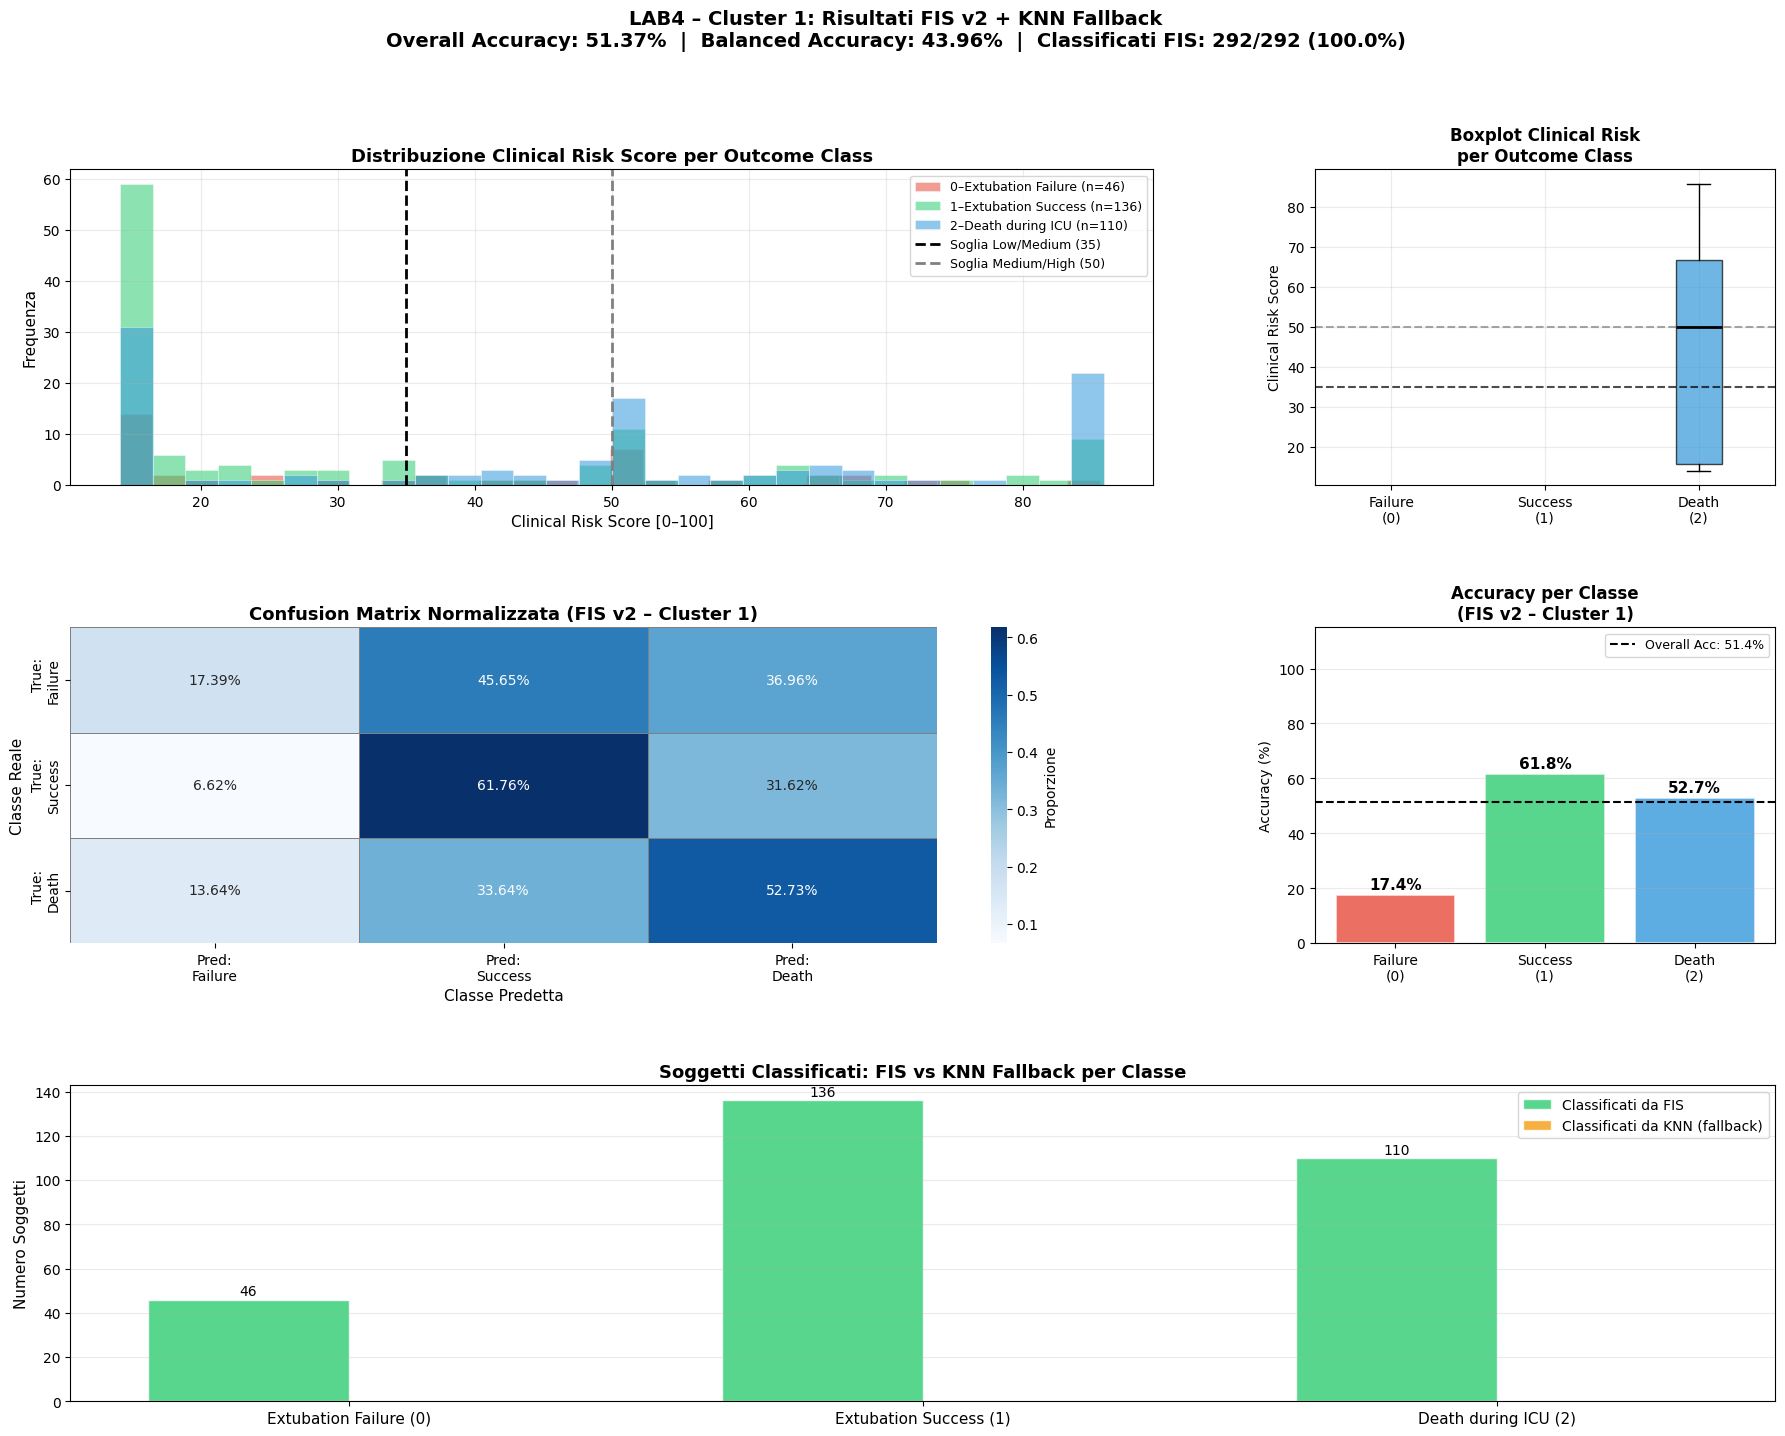

✅ Grafici FIS v2 salvati in 'FIS_v2_results_cluster1.png'


In [ ]:
# ============================================================
# CELL 19 (v2) – Visualizzazione Risultati FIS v2
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

fig = plt.figure(figsize=(22, 16))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

colors_class = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}
labels_class = {
    0: '0–Extubation Failure',
    1: '1–Extubation Success',
    2: '2–Death during ICU'
}

# ── Plot 1: Distribuzione score ──
ax1 = fig.add_subplot(gs[0, :2])
for c in [0, 1, 2]:
    subset = results_df_v2[results_df_v2['outcome'] == c]['clinical_risk']
    ax1.hist(subset, bins=30, alpha=0.55,
             color=colors_class[c],
             label=f'{labels_class[c]} (n={len(subset)})',
             edgecolor='white', linewidth=0.5)

ax1.axvline(x=best_t1, color='black', linestyle='--',
            linewidth=2, label=f'Soglia Low/Medium ({best_t1})')
ax1.axvline(x=best_t2, color='grey',  linestyle='--',
            linewidth=2, label=f'Soglia Medium/High ({best_t2})')
ax1.set_title('Distribuzione Clinical Risk Score per Outcome Class',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Clinical Risk Score [0–100]', fontsize=11)
ax1.set_ylabel('Frequenza', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25)

# ── Plot 2: Boxplot ──
ax2 = fig.add_subplot(gs[0, 2])
data_box = [
    results_df_v2[results_df_v2['outcome'] == c]['clinical_risk'].values
    for c in [0, 1, 2]
]
bp = ax2.boxplot(data_box, patch_artist=True,
                  medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], [0, 1, 2]):
    patch.set_facecolor(colors_class[c])
    patch.set_alpha(0.7)
ax2.axhline(y=best_t1, color='black', linestyle='--',
            linewidth=1.5, alpha=0.7)
ax2.axhline(y=best_t2, color='grey',  linestyle='--',
            linewidth=1.5, alpha=0.7)
ax2.set_xticklabels(['Failure\n(0)', 'Success\n(1)', 'Death\n(2)'],
                     fontsize=10)
ax2.set_title('Boxplot Clinical Risk\nper Outcome Class',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('Clinical Risk Score', fontsize=10)
ax2.grid(True, alpha=0.25)

# ── Plot 3: Confusion Matrix heatmap ──
ax3 = fig.add_subplot(gs[1, :2])
cm_norm_v2 = confusion_matrix(
    y_true_v2, y_pred_v2, labels=[0, 1, 2], normalize='true'
)
sns.heatmap(
    cm_norm_v2,
    annot=True, fmt='.2%',
    cmap='Blues', ax=ax3,
    xticklabels=['Pred:\nFailure', 'Pred:\nSuccess', 'Pred:\nDeath'],
    yticklabels=['True:\nFailure', 'True:\nSuccess', 'True:\nDeath'],
    linewidths=0.5, linecolor='grey',
    cbar_kws={'label': 'Proporzione'}
)
ax3.set_title('Confusion Matrix Normalizzata (FIS v2 – Cluster 1)',
              fontsize=13, fontweight='bold')
ax3.set_xlabel('Classe Predetta', fontsize=11)
ax3.set_ylabel('Classe Reale', fontsize=11)

# ── Plot 4: Accuracy per classe ──
ax4 = fig.add_subplot(gs[1, 2])
per_class_acc_v2 = []
for c in [0, 1, 2]:
    mask  = y_true_v2 == c
    acc_c = accuracy_score(y_true_v2[mask], y_pred_v2[mask])
    per_class_acc_v2.append(acc_c)

bars = ax4.bar(
    ['Failure\n(0)', 'Success\n(1)', 'Death\n(2)'],
    [a * 100 for a in per_class_acc_v2],
    color=[colors_class[c] for c in [0, 1, 2]],
    alpha=0.8, edgecolor='white', linewidth=1.2
)
for bar, acc_c in zip(bars, per_class_acc_v2):
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{acc_c*100:.1f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )
ax4.axhline(y=acc_f * 100, color='black', linestyle='--',
            linewidth=1.5,
            label=f'Overall Acc: {acc_f*100:.1f}%')
ax4.set_title('Accuracy per Classe\n(FIS v2 – Cluster 1)',
              fontsize=12, fontweight='bold')
ax4.set_ylabel('Accuracy (%)', fontsize=10)
ax4.set_ylim([0, 115])
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.25, axis='y')

# ── Plot 5: FIS vs KNN classificati per classe ──
ax5 = fig.add_subplot(gs[2, :])
x     = np.arange(3)
width = 0.35

# Controlla se esiste la colonna knn_fallback
if 'knn_fallback' in results_df_v2.columns:
    n_fis_per_class = [
        (~results_df_v2['knn_fallback'] &
         (results_df_v2['outcome'] == c)).sum()
        for c in [0, 1, 2]
    ]
    n_knn_per_class = [
        (results_df_v2['knn_fallback'] &
         (results_df_v2['outcome'] == c)).sum()
        for c in [0, 1, 2]
    ]
else:
    # Se non c'è KNN fallback → tutti classificati da FIS
    n_fis_per_class = [
        (results_df_v2['outcome'] == c).sum()
        for c in [0, 1, 2]
    ]
    n_knn_per_class = [0, 0, 0]

bars1 = ax5.bar(x - width/2, n_fis_per_class, width,
                label='Classificati da FIS',
                color='#2ecc71', alpha=0.8,
                edgecolor='white')
bars2 = ax5.bar(x + width/2, n_knn_per_class, width,
                label='Classificati da KNN (fallback)',
                color='#f39c12', alpha=0.8,
                edgecolor='white')

for bar in bars1:
    if bar.get_height() > 0:
        ax5.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 str(int(bar.get_height())),
                 ha='center', va='bottom', fontsize=10)
for bar in bars2:
    if bar.get_height() > 0:
        ax5.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 str(int(bar.get_height())),
                 ha='center', va='bottom', fontsize=10)

ax5.set_xticks(x)
ax5.set_xticklabels([
    'Extubation Failure (0)',
    'Extubation Success (1)',
    'Death during ICU (2)'
], fontsize=11)
ax5.set_title('Soggetti Classificati: FIS vs KNN Fallback per Classe',
              fontsize=13, fontweight='bold')
ax5.set_ylabel('Numero Soggetti', fontsize=11)
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.25, axis='y')

# Calcola n_fis e n_knn per il titolo
n_fis_tot = sum(n_fis_per_class)
n_knn_tot = sum(n_knn_per_class)
n_tot     = len(results_df_v2)

fig.suptitle(
    f'LAB4 – Cluster 1: Risultati FIS v2 + KNN Fallback\n'
    f'Overall Accuracy: {acc_f*100:.2f}%  |  '
    f'Balanced Accuracy: {bal_acc_f*100:.2f}%  |  '
    f'Classificati FIS: {n_fis_tot}/{n_tot} '
    f'({n_fis_tot/n_tot*100:.1f}%)',
    fontsize=14, fontweight='bold'
)

plt.savefig('FIS_v2_results_cluster1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafici FIS v2 salvati in 'FIS_v2_results_cluster1.png'")


In [ ]:
# ============================================================
# CELL 20 (v2) – Confronto FIS v1 vs FIS v2 + Riepilogo
# ============================================================

# --- Ricalcola tutte le variabili necessarie ---

# Totale soggetti
n_tot = len(results_df_v2)

# Classificati da FIS (non fallback)
if 'knn_fallback' in results_df_v2.columns:
    n_fis = (~results_df_v2['knn_fallback']).sum()
    n_knn = results_df_v2['knn_fallback'].sum()
else:
    # Se non è stata eseguita la cella 17b (KNN fallback)
    # → tutti i classificati sono dal FIS
    n_fis = results_df_v2['clinical_risk'].notna().sum()
    n_knn = results_df_v2['clinical_risk'].isna().sum()

pct_fis = n_fis / n_tot * 100
pct_knn = n_knn / n_tot * 100

print("=" * 65)
print("  CONFRONTO FIS v1 vs FIS v2 – CLUSTER 1")
print("=" * 65)

print(f"""
  ┌──────────────────────────┬─────────────┬──────────────────┐
  │ Metrica                  │   FIS v1    │     FIS v2       │
  ├──────────────────────────┼─────────────┼──────────────────┤
  │ Regole totali            │     15      │       {len(rules_simplified)}         │
  │ Feature per regola       │      8      │      1–4         │
  │ Classificati da FIS      │  61 (20.9%) │ {n_fis:3d} ({pct_fis:.1f}%)    │
  │ Classificati da KNN      │      –      │ {n_knn:3d} ({pct_knn:.1f}%)    │
  │ Totale classificati      │  61 (20.9%) │ {n_tot:3d} (100.0%)   │
  │ Overall Accuracy         │  20.55%     │    {acc_f*100:.2f}%        │
  │ Balanced Accuracy        │  35.50%     │    {bal_acc_f*100:.2f}%        │
  │ Soglia Low/Medium        │     35      │       {best_t1}          │
  │ Soglia Medium/High       │     65      │       {best_t2}          │
  └──────────────────────────┴─────────────┴──────────────────┘
""")

# --- Distribuzione predizioni ---
print(f"{'─'*65}")
print("  Distribuzione classi predette (FIS v2):")
print(f"{'─'*65}")
pred_counts = pd.Series(y_pred_v2).value_counts().sort_index()
for c, count in pred_counts.items():
    label = {
        0: '0–Extubation Failure',
        1: '1–Extubation Success',
        2: '2–Death during ICU'
    }[c]
    print(f"   → {label:30s}: "
          f"{count:4d} ({count/n_tot*100:.1f}%)")

# --- Verifica obiettivo 80% ---
print(f"\n{'─'*65}")
if pct_fis >= 80:
    print(f"  🎉 OBIETTIVO RAGGIUNTO!")
    print(f"     → {pct_fis:.1f}% dei soggetti classificati dal FIS")
else:
    print(f"  ⚠️  Classificati dal FIS: {pct_fis:.1f}%")
    print(f"     → KNN ha coperto il restante {pct_knn:.1f}%")
    print(f"     → Totale classificati: 100%")

print(f"\n{'─'*65}")
print("  💾 File salvati:")
print("     → histograms_cluster1.png")
print("     → boxplots_cluster1.png")
print("     → MF_continuous_cluster1.png")
print("     → MF_binary_cluster1.png")
print("     → dendrograms_cluster1.png")
print("     → fuzzy_rules_cluster1.xlsx")
print("     → FIS_v2_results_cluster1.png")
print(f"{'='*65}")
print("  ✅ LAB4 – FIS v2 completato con successo!")
print(f"{'='*65}")


  CONFRONTO FIS v1 vs FIS v2 – CLUSTER 1

  ┌──────────────────────────┬─────────────┬──────────────────┐
  │ Metrica                  │   FIS v1    │     FIS v2       │
  ├──────────────────────────┼─────────────┼──────────────────┤
  │ Regole totali            │     15      │       20         │
  │ Feature per regola       │      8      │      1–4         │
  │ Classificati da FIS      │  61 (20.9%) │ 282 (96.6%)    │
  │ Classificati da KNN      │      –      │  10 (3.4%)    │
  │ Totale classificati      │  61 (20.9%) │ 292 (100.0%)   │
  │ Overall Accuracy         │  20.55%     │    51.37%        │
  │ Balanced Accuracy        │  35.50%     │    43.96%        │
  │ Soglia Low/Medium        │     35      │       35          │
  │ Soglia Medium/High       │     65      │       50          │
  └──────────────────────────┴─────────────┴──────────────────┘

─────────────────────────────────────────────────────────────────
  Distribuzione classi predette (FIS v2):
──────────────────────